# PPMA EFM Interpretability — SHAP → Integrated Gradients

Runs in a **SageMaker Studio JupyterLab GPU space** (validated on an **A10G**).
- **Stage 1 (SHAP)** is precomputed → we use the confirmed `TOP_DIMS` constant
  (optionally reproduce it live via `databricks-sql-connector`).
- **Stage 2 (IG)** loads the fine-tuned EFM on the GPU and uses `LayerIntegratedGradients` on the
  token-embedding layer to trace each top embedding dim back to input transaction tokens.

Run order: **Setup → Config → (Stage-1 optional) → load model → IG machinery → smoke test → real run**.
End-to-end validated against the real `checkpoint-120000`: the real run pulls the packed eval bake +
tokenizer from S3, runs IG per user, and decodes the top transactions per dim.

Note: `/tmp` and pip installs are ephemeral here — re-running Setup + the load/pull cells re-fetches
everything (they're idempotent). Stop the GPU space when done (it bills while Running).

In [1]:
# === Setup ===
# captum + peft are the only extra installs. The EFM library is used in-place from the
# cloned repo via sys.path — an editable install would try to resolve private Artifactory
# deps (ml-platform, ml-features) we don't need here.
%pip install -q --no-deps captum "peft==0.17.1"

import os, sys, json
import numpy as np
import torch

EFM_REPO = "/home/sagemaker-user/Develop/efm-token-decoder"
for _p in (f"{EFM_REPO}/code/src", f"{EFM_REPO}/code"):   # code/src: efm_core+efm_finetune; code: scripts
    if _p not in sys.path:
        sys.path.insert(0, _p)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("CUDA available:", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "(CPU)")   # MUST be a GPU space

Note: you may need to restart the kernel to use updated packages.


CUDA available: True NVIDIA A10G


In [2]:
# === Config (confirmed from the checkpoint's config.json, 2026-06-17) ===
EMB_PREFIX    = "decoder39k_ppma_lora_emb_"
EMBEDDING_DIM = 768
MODEL_DIM     = 768
POOL_METHOD   = "last_token"   # is_causal=True + ckpt pool_method="default" -> last_token (matches production)
EOS_TOKEN_ID  = None           # unused by last_token pooling
ATTN_BACKEND  = "sdpa"         # this space is an A10G (no FlashAttention-3); override the ckpt's fa3

# --- Stage 1 result: top embedding dims by mean(|SHAP|) on the LightGBM PPMA scorer ---
# PRIORITY = emb dims that rank high OVERALL (beat/compete with the tabular features):
TOP_DIMS       = [277, 479, 303, 714, 85, 687, 317, 231, 507, 514, 249, 666]
# Lower-priority emb dims (rank below several tabular features) — broader exploration only:
TOP_DIMS_EXTRA = [223, 624, 253, 684, 242, 13, 589, 482]
# NOTE: the OVERALL top-20 is ~12 emb + ~8 tabular (bank_available_balance_RCT, gps_work_location_approved_NDR,
# debit_card_current_valid_card_tenure_NDF, device_model_RCT, payroll_paycycle_frequency_RCT, bank_payroll_*).
# Only the emb dims are IG-traceable (they're EFM outputs); the tabular features are explained by SHAP alone.

# --- Stage 2: the fine-tuned checkpoint (pulled from S3; see load_ft_model below) ---
# config.json facts (verified): model_type=efm-finetune, is_causal=True, peft_method=lora,
#   amount_channel_mode="none", joint_fusion_enabled=False, model_dim=768, num_layers=12,
#   num_heads=12, num_kv_heads=3, vocab_size=16386, pad_token_id=0, rope theta=500000.
# This is an HF Trainer MID-RUN ckpt of a LoRA run -> model.safetensors holds UNMERGED adapter
#   keys; load_ft_model recreates the PEFT wrapper, loads, and merges (from_pretrained alone would
#   silently re-init the backbone -> noise).
# amount_channel_mode="none" => no continuous PLR/abacus path: amounts enter ONLY via the discrete
#   [type_*]/[amt_sign_*]/[amt_bin_*] tokens, which token-level IG fully captures. The HANDOFF
#   "attribute amount_cents separately" caveat does NOT apply to THIS checkpoint.
FT_CHECKPOINT_S3    = "s3://ml-hyperpod-fsx-datalakeprod-us-west-2/runs/efm-ppma-ft-decoder100m-h100-20260519-142518Z/checkpoints/checkpoint-120000"
FT_CHECKPOINT_LOCAL = "/home/sagemaker-user/Develop/Explainability/_cache/efm_ft_ckpt"

# --- Per-user IG inputs: tokenized transaction sequences (deferred — smoke first) ---
SEQUENCES_S3 = None        # TODO: resolve real per-user sequence source (lean: reuse the FT eval bake)

## Stage 1 — SHAP (precomputed; reproduce only if you want to confirm)
The values are already logged. `TOP_DIMS` above is the result. The cell below re-derives it live
via `databricks-sql-connector` — optional, for auditing. Needs a PAT (store in Secrets Manager,
never hardcode) and the SQL warehouse HTTP path.

In [3]:
def reproduce_top_dims(limit_rows=20000, k=20, emb_only=True):
    from databricks import sql
    where = "WHERE key RLIKE 'lora_emb_[0-9]+$'" if emb_only else ""
    q = f"""
      SELECT key, avg(abs(value)) AS m FROM (
        SELECT explode(from_json(to_json(s),'map<string,double>')) AS (key,value)
        FROM (SELECT response.shap_values AS s
              FROM main_prod.ml_data.efm_ppma_v1_inference_log LIMIT {limit_rows}) t
      ) {where} GROUP BY key ORDER BY m DESC LIMIT {k}
    """
    with sql.connect(
        server_hostname="earnin-earnin-prod.cloud.databricks.com",
        http_path=os.environ["DATABRICKS_HTTP_PATH"],     # SQL Warehouses -> Connection details
        access_token=os.environ["DATABRICKS_TOKEN"],      # PAT from Secrets Manager / env — NOT hardcoded
    ) as c, c.cursor() as cur:
        cur.execute(q)
        return cur.fetchall()

# rows = reproduce_top_dims(); print(rows)   # uncomment to confirm; should match TOP_DIMS / §7.4

## Stage 2 — Integrated Gradients (GPU)
Trace each top dim back to the input transactions. `base_value` for the additivity check is logged at
`response.shap_values.base_value` (≈ 4.97).

In [4]:
# --- Load the fine-tuned EFM checkpoint (LoRA mid-run ckpt -> apply_peft, load, merge) ---
from safetensors.torch import load_file as load_safetensors
from efm_finetune.model.config import EFMFineTuneConfig
from efm_finetune.model.finetune_model import EFMForFineTuning
from efm_finetune.peft.wrap import apply_peft
from efm_finetune.head.pooling import pool_sequence

def pull_checkpoint(local=FT_CHECKPOINT_LOCAL, s3=FT_CHECKPOINT_S3):
    os.makedirs(local, exist_ok=True)
    for f in ("config.json", "model.safetensors"):
        if not os.path.exists(f"{local}/{f}"):
            rc = os.system(f"aws s3 cp {s3}/{f} {local}/{f}")
            if rc != 0:
                raise RuntimeError(f"aws s3 cp failed for {f} (rc={rc}); "
                                   "check the SageMaker execution role's S3 read access")
    return local

def load_ft_model(local=FT_CHECKPOINT_LOCAL, device=DEVICE, dtype=torch.float32, attn_backend=ATTN_BACKEND):
    """Load the PPMA fine-tune for inference.

    The S3 path is an HF Trainer mid-run checkpoint of a LoRA run, so model.safetensors holds the
    *unmerged* PEFT wrapper keys. EFMForFineTuning.from_pretrained would build a bare (unwrapped)
    backbone and silently re-init it on the key mismatch -> noise. Instead recreate the wrapper,
    load strict=False, and merge the adapter (mirrors eval/embedding_extractor.load_model_for_eval).
    fp32 for clean IG gradients; attn_backend=sdpa because the A10G has no FlashAttention-3.
    """
    pull_checkpoint(local)
    cfg = EFMFineTuneConfig.from_pretrained(local, attn_backend=attn_backend, dropout=0.0)
    model = EFMForFineTuning(cfg)
    if cfg.peft_method in ("lora", "dora"):
        model.model = apply_peft(model.model, cfg)
    sd = load_safetensors(f"{local}/model.safetensors")
    missing, unexpected = model.load_state_dict(sd, strict=False)
    # Missing backbone keys = silently-uninitialized weights = noise; fail loud. (Validated: 0/0.)
    assert not missing, f"missing state_dict keys (backbone would be re-init'd): {missing[:8]}"
    if unexpected:
        print("note: unexpected keys ignored:", unexpected[:8])
    model.merge_peft_into_backbone()   # model.model becomes a clean EFMModel
    return model.to(dtype).to(device).eval()

model = load_ft_model()
TOKEN_EMBEDDING_LAYER = model.get_input_embeddings()   # backbone token_embeddings (nn.Embedding), 16386x768
print("loaded:", type(model.model).__name__,
      "| token emb", tuple(TOKEN_EMBEDDING_LAYER.weight.shape),
      "| amount_channel_mode", model.config.amount_channel_mode,
      "| pool", POOL_METHOD)

2026-06-24 17:01:07.779003: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782320467.807075   12774 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782320467.820250   12774 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782320468.005543   12774 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782320468.006129   12774 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782320468.006132   12774 computation_placer.cc:177] computation placer alr

loaded: EFMModel | token emb (16386, 768) | amount_channel_mode none | pool last_token


In [5]:
# --- The IG machinery (used by both the smoke test and the real run) ---
from captum.attr import LayerIntegratedGradients

def embedding_forward(input_ids, cu_seqlens, position_ids, max_seqlen):
    """Pooled (last-token) embedding so Captum `target=d` selects emb dim d.

    Uses encode_hidden_states (returns the (1, T, 768) tensor directly), NOT model.model(...)
    which returns a BaseModelOutput. amount_channel_mode='none' on this ckpt -> no amount tensors.
    """
    hidden = model.model.encode_hidden_states(
        input_ids=input_ids, cu_seqlens=cu_seqlens,
        position_ids=position_ids, max_seqlen=max_seqlen,
    )  # (1, T, 768)
    return pool_sequence(hidden, cu_seqlens, is_causal=bool(model.config.is_causal),
                         pool_method=POOL_METHOD, input_ids=input_ids, eos_token_id=EOS_TOKEN_ID)  # (1, 768)

def attribute_dims(input_ids, cu_seqlens, position_ids, max_seqlen, dims, n_steps=64, baseline_ids=None):
    """Per-token IG attribution for each target embedding dim.

    Returns {dim: {"per_token": (T,) np.ndarray, "conv_delta": float}}.

    internal_batch_size=1 is REQUIRED: EFM's packed varlen forward hard-requires batch dim 1, but
    Captum otherwise stacks the n_steps interpolations along dim 0 (-> (n_steps, T, 768)) and would
    also wrongly expand cu_seqlens/position_ids. =1 runs one interpolation step per forward.
    """
    lig = LayerIntegratedGradients(embedding_forward, TOKEN_EMBEDDING_LAYER)
    if baseline_ids is None:
        baseline_ids = torch.zeros_like(input_ids)   # all [pad] (id 0); baseline choice is OPEN (see methods-draft.md)
    out = {}
    for d in dims:
        attr, delta = lig.attribute(
            inputs=input_ids, baselines=baseline_ids, target=int(d),
            additional_forward_args=(cu_seqlens, position_ids, max_seqlen),
            n_steps=n_steps, internal_batch_size=1, return_convergence_delta=True,
        )
        out[int(d)] = {
            "per_token": attr.sum(dim=-1).squeeze(0).detach().cpu().numpy(),  # (T,) sum over the 768 emb-grad dims
            "conv_delta": float(delta.item()),                               # IG completeness check (want ~0)
        }
    return out
# NOTE: amount_channel_mode="none" on this ckpt, so token-level IG captures amounts fully (via the
# discrete [type_*]/[amt_sign_*]/[amt_bin_*] tokens). If a future ckpt enables the PLR/abacus amount
# channel, that continuous path bypasses the token-embedding layer and amount magnitude must be
# attributed separately (over amount_cents).

In [6]:
# === SMOKE TEST: validate the full IG path on the loaded REAL model with a dummy input ===
# Attributions are MEANINGLESS here (random token ids) — this only confirms the plumbing:
#   load -> encode_hidden_states -> last-token pool -> LayerIntegratedGradients -> (T,) per-token attr.
# Expect: pooled (1, 768) finite, per-token shape (T,), and conv_delta ~ 0 (IG completeness).
T = 64
_ids = torch.randint(5, model.config.vocab_size, (1, T)).to(DEVICE)        # avoid special tokens (<5)
_cu  = torch.tensor([0, T], dtype=torch.int32, device=DEVICE)              # one segment
_pos = torch.arange(T, dtype=torch.int32, device=DEVICE).view(1, -1)

with torch.no_grad():
    _pooled = embedding_forward(_ids, _cu, _pos, T)
print("pooled embedding:", tuple(_pooled.shape), "finite:", bool(torch.isfinite(_pooled).all()))

_smoke = attribute_dims(_ids, _cu, _pos, T, TOP_DIMS[:3], n_steps=32)
for d, r in _smoke.items():
    pt = r["per_token"]
    print(f"dim {d:>3}: per_token {pt.shape} | sum {pt.sum():+.4f} | conv_delta {r['conv_delta']:+.2e}")
print("SMOKE OK — IG plumbing validated on the real checkpoint.")

pooled embedding: (1, 768) finite: True


dim 277: per_token (64,) | sum +9.4605 | conv_delta -2.75e-04
dim 479: per_token (64,) | sum -0.3539 | conv_delta -1.03e-04
dim 303: per_token (64,) | sum -0.4591 | conv_delta -7.42e-05
SMOKE OK — IG plumbing validated on the real checkpoint.


## Real run — per-user IG from the packed bake, decoded to transaction tokens

Each user's full sequence is run as **one packed segment** (`cu_seqlens=[0, T]`), so last-token pooling
gives exactly that user's production embedding. Two views per dim: **per-transaction** rollups (sum on
`[txn_sep]` spans, shown as `txn k/N`) and **per-token** content (structural markers excluded).

**Inputs resolved (both in S3, reachable here):**
- **Packed bake (gold IG inputs)** — exact tokenized sequences the model was eval'd on:
  `s3://ml-datasets-datalakeprod-us-west-2-sagemaker/efm_risk_ppma_finetune_dataset/3/baked/efm-tokenizer-mlm-1778761485-amt64/seq16384_tb16384_mc0_tdnone_bcv6/{val,train}/`.
  FT `multi_chunk=False` ⇒ each user is **one contiguous segment**; split by `cu_seqlens`. No tokenizer
  needed to *run* IG — only to **decode** ids → tokens.
- **Tokenizer artifact** (decoding): `…/runs/efm-ppma-ft-decoder100m-…/outputs/model/`.

**Empirical findings:**
- `n_steps=32` under-converges (conv_delta ≈ 4.9 on a real 1.3k-token user); **`n_steps≥64`** → conv_delta ≈ 0.
- **Baseline = the contrast** (any position where baseline==input gets ~0 attribution). Default is the
  field-wise **`[none]` empty-transaction baseline** (`make_baseline(kind="none")`): structural markers +
  amount/time scaffolding held fixed, content fields nulled. It **surfaces the named entities**
  (merchant/lender/category) — e.g. dim 277 → `upstart`, `creditgenie`, `synchrony`, `greenlight`, `zip`,
  `pypl` — and removes the recency/structural dominance by construction. (`kind="eos"`/`"pad"` are
  diagnostic-only contrasts that instead light up recent-txn scaffolding. Read `[none]` magnitudes as a
  *ranking* — they're the marginal effect of content identity, small and not comparable across baselines.)
  Eventual gold standard: **expected gradients** ("vs. a typical user").
- **Read token semantics from the token NAME** (`[cat_*]`/`[bank_name_*]`/`[amt_bin_*]`/`[month_*]`…), not
  its positional slot — this bake's field-slots don't always match the current sequence_builder template
  (e.g. a `[cat_*]` token can appear in the bank slot).

`iter_user_sequences_from_raw` (raw transactions → tokenize) is kept below as an alternative path. Governed
data — keep results in this space; do not export raw rows / user ids.

In [7]:
# --- Per-user packing, bake reader, decoding, transaction- AND token-level aggregation ---
from glob import glob
import pyarrow as pa
from efm_core.data.sequence_builder import (
    BOS_TOKEN, EOS_TOKEN, TXN_SEP_TOKEN, STRUCTURAL_TOKENS,
    build_transaction_sequence, build_transaction_interface_config,
)
from efm_core.data.tokenizer_runtime import load_pretrained_tokenizer_runtime

# Resolved input sources (S3, reachable from this space):
BAKE_S3    = "s3://ml-datasets-datalakeprod-us-west-2-sagemaker/efm_risk_ppma_finetune_dataset/3/baked/efm-tokenizer-mlm-1776745486/seq16384_tb16384_mc0_tdnone_bcv6/val"  # MATCHES the model (interface_config_id 225ef2ba); the -1778761485-amt64 bake was a DIFFERENT tokenizer (wrong inputs)
TOK_S3     = "s3://ml-hyperpod-fsx-datalakeprod-us-west-2/runs/efm-ppma-ft-decoder100m-h100-20260519-142518Z/outputs/model"  # the MODEL's tokenizer (interface_config_id 225ef2ba, vocab 16386); matches checkpoint-120000 AND the 1776745486 bake
BAKE_LOCAL = "/home/sagemaker-user/Develop/Explainability/_cache/efm_ppma_bake_1776745486_val"
TOK_LOCAL  = "/home/sagemaker-user/Develop/Explainability/_cache/efm_tokenizer"
N_STEPS    = 64    # >=64: n_steps=32 under-converged (conv_delta~4.9) on real 1.3k-token seqs; 64 -> conv_delta ~0

def build_user_pack(token_ids, device=DEVICE):
    """One user's token-id list -> (input_ids, cu_seqlens, position_ids, max_seqlen) as a SINGLE segment,
    so last-token pooling yields that user's production embedding."""
    T = len(token_ids)
    input_ids    = torch.tensor(token_ids, dtype=torch.long, device=device).view(1, T)
    cu_seqlens   = torch.tensor([0, T], dtype=torch.int32, device=device)
    position_ids = torch.arange(T, dtype=torch.int32, device=device).view(1, T)
    return input_ids, cu_seqlens, position_ids, T

def _txn_bounds(token_ids, txn_sep_id):
    """Transaction span boundaries from [txn_sep] positions. Returns (bounds, n_txn)."""
    seps = [i for i, t in enumerate(token_ids) if t == txn_sep_id]
    bounds = [0] + [s + 1 for s in seps] + [len(token_ids)]
    return bounds, len(bounds) - 1

def aggregate_tokens_to_transactions(per_token, token_ids, txn_sep_id, exclude_ids=frozenset()):
    """Per-transaction attribution. Splits on [txn_sep]; sums per-token attr within each transaction,
    EXCLUDING any token in exclude_ids (e.g. [bos]/[eos]) so seam/pooling tokens don't inflate a txn.
    Returns [{idx, n, start, end, attr}] in sequence order (idx is 1-based: transaction idx/n)."""
    bounds, n = _txn_bounds(token_ids, txn_sep_id)
    spans = []
    for k, (a, b) in enumerate(zip(bounds[:-1], bounds[1:])):
        s = float(sum(per_token[i] for i in range(a, b) if token_ids[i] not in exclude_ids))
        spans.append({"idx": k + 1, "n": n, "start": a, "end": b, "attr": s})
    return spans

def top_content_tokens(per_token, token_ids, structural_ids, txn_of_pos, k=6):
    """Top-k individual tokens by |attr|, EXCLUDING structural markers ([txn_type]/[amount]/[bank]/...
    /[bos]/[eos]/[txn_sep]). Returns [(pos, txn_idx, token_id, attr)]. Read semantics from the token's
    OWN name (prefix) — [cat_*]=category, [bank_name_*]=bank, [amt_bin_*]=amount, [month_*]/[dom_*]/
    [weekday_*]=time — NOT from its positional slot (this bake's field-slots don't always match the
    current sequence_builder template; e.g. a [cat_*] token can appear in the bank slot)."""
    out = []
    for i in np.argsort(-np.abs(per_token)):
        if token_ids[i] in structural_ids:
            continue
        out.append((int(i), txn_of_pos[int(i)], token_ids[int(i)], float(per_token[i])))
        if len(out) >= k:
            break
    return out

def make_baseline(token_ids, runtime, kind="none", device=DEVICE):
    """IG reference sequence (same length as input). The baseline IS the contrast: any position where
    baseline == input gets ~0 attribution (zero-length integration path).

    - "none" (DEFAULT, recommended): field-wise EMPTY-TRANSACTION baseline. Keep structural markers
      (STRUCTURAL_TOKENS) and [type_*]/[amt_sign_*] identical; none-out the informative content —
      [cat_*]->[cat_none], [bank_*]->[bank_none], [month_*]/[dom_*]/[weekday_*]->[*_none],
      [amt_bin*]->[amt_bin_underflow], merchant/desc free-text->[none]. Attribution then concentrates
      on the NAMED content fields (merchant/category/bank/amount/time) and the recency/structural-token
      dominance vanishes by construction. This is methods-draft.md's template-valid "[none]-sentinel".
      NOTE: read magnitudes as a *ranking* — they are the marginal effect of content identity (small),
      not comparable to the "eos"/"pad" contrasts.
    - "eos" / "pad": all-[eos] / all-[pad] uniform references. Well-/ill-conditioned numerically but NOT
      a meaningful contrast (every position differs, so structural scaffolding dominates). Kept for
      diagnostics. Expected-gradients ("vs. a typical user", avg over a reference population) is the
      eventual gold standard for the risk question.
    """
    v = runtime.vocab
    if kind in ("eos", "pad"):
        tok = v[EOS_TOKEN] if kind == "eos" else 0
        return torch.full((1, len(token_ids)), tok, dtype=torch.long, device=device)
    if kind != "none":
        raise ValueError(f"unknown baseline kind={kind!r}")
    id2tok = {i: t for t, i in v.items()}
    struct = set(STRUCTURAL_TOKENS)
    out = []
    for t in token_ids:
        s = id2tok.get(t, "")
        if s in struct or s.startswith("[type_") or s.startswith("[amt_sign_"):
            out.append(t)                                    # keep identical -> ~0 attribution
        elif s.startswith("[cat_"):       out.append(v["[cat_none]"])
        elif s.startswith("[bank_name_") or s in ("[bank_unk]", "[bank_none]"): out.append(v["[bank_none]"])
        elif s.startswith("[month_"):     out.append(v["[month_none]"])
        elif s.startswith("[dom_"):       out.append(v["[dom_none]"])
        elif s.startswith("[weekday_"):   out.append(v["[weekday_none]"])
        elif s.startswith("[amt_bin"):    out.append(v["[amt_bin_underflow]"])
        else:                             out.append(v["[none]"])   # merchant/desc free-text, etc.
    return torch.tensor(out, dtype=torch.long, device=device).view(1, -1)

# ---- Input source A (GOLD): the packed eval bake — exact tokenized sequences, split per user ----
def pull_bake(n_shards=1, local=BAKE_LOCAL, s3=BAKE_S3):
    os.makedirs(local, exist_ok=True)
    if not os.path.exists(f"{local}/bake_manifest.json"):
        os.system(f"aws s3 cp {s3}/bake_manifest.json {local}/bake_manifest.json")
    for i in range(n_shards):
        f = f"merged-algo-1-{i:06d}.arrow"
        if not os.path.exists(f"{local}/{f}"):
            os.system(f"aws s3 cp {s3}/{f} {local}/{f}")
    return sorted(glob(f"{local}/*.arrow"))

def pull_tokenizer(local=TOK_LOCAL, s3=TOK_S3):
    os.makedirs(f"{local}/tokenizer", exist_ok=True)
    for rel in ("interface_config.json", "tokenizer/tokenizer.json"):
        if not os.path.exists(f"{local}/{rel}"):
            os.system(f"aws s3 cp {s3}/{rel} {local}/{rel}")
    return load_pretrained_tokenizer_runtime(local)

def iter_user_sequences_from_bake(arrow_files, max_users=None, max_len=None):
    """Yield (user_id, token_ids, label, pred_time). FT multi_chunk=False => each user is one contiguous
    segment; user_ids lists only real segments (trailing pad segment is skipped). Reads Arrow IPC directly."""
    n = 0
    for f in arrow_files:
        reader = pa.ipc.open_file(pa.memory_map(f, "r"))
        for bi in range(reader.num_record_batches):
            for row in reader.get_record_batch(bi).to_pylist():
                cu = row["cu_seqlens"]
                for si, uid in enumerate(row["user_ids"]):
                    ids = row["input_ids"][cu[si]:cu[si + 1]]
                    if max_len and len(ids) > max_len:
                        continue
                    yield uid, ids, row["labels_per_segment"][si], row["pred_times"][si]
                    n += 1
                    if max_users and n >= max_users:
                        return

def report_user(uid, token_ids, attr, id2tok, txn_sep_id, structural_ids, bos_eos_ids,
                dims=None, topk_txn=3, topk_tok=6, max_tok=20):
    """Per dim: top transactions (idx/N, [bos]/[eos] excluded from the sum) AND top content tokens
    (structural markers excluded). Transaction position is shown as `txn k/N` (k=1 oldest .. N newest)."""
    dims = dims or list(attr)
    bounds, N = _txn_bounds(token_ids, txn_sep_id)
    txn_of_pos = {i: k + 1 for k, (a, b) in enumerate(zip(bounds[:-1], bounds[1:])) for i in range(a, b)}
    print(f"\n========== user {uid} | T={len(token_ids)} | {N} transactions ==========")
    for d in dims:
        pt = attr[d]["per_token"]
        spans = aggregate_tokens_to_transactions(pt, token_ids, txn_sep_id, exclude_ids=bos_eos_ids)
        top_txn = sorted(spans, key=lambda s: abs(s["attr"]), reverse=True)[:topk_txn]
        print(f"\n dim {d} (conv_delta {attr[d]['conv_delta']:+.2f})")
        print(f"   top {topk_txn} transactions by |attr| (sum over txn tokens; [bos]/[eos] excluded):")
        for s in top_txn:
            toks = " ".join(id2tok.get(i, str(i)) for i in token_ids[s["start"]:s["end"]][:max_tok])
            print(f"     txn {s['idx']:>3}/{N}  attr={s['attr']:+8.3f}  {toks}")
        print(f"   top {topk_tok} content tokens by |attr| (structural markers excluded):")
        for pos, k, tid, a in top_content_tokens(pt, token_ids, structural_ids, txn_of_pos, k=topk_tok):
            print(f"     txn {k:>3}/{N}  attr={a:+8.3f}  {id2tok.get(tid, tid)}")

# ---- Input source B (alt): raw transactions -> tokenize on the fly (full-schema FT dataset rows) ----
def tokenize_user(runtime, *, descriptions, amount_cents, postedon_list_seconds,
                  bank_names, categories, merchant_names, max_seq_len=16384):
    """Build [bos] txn [txn_sep] ... [eos], keeping the most-recent WHOLE transactions that fit max_seq_len
    (mirrors the FT recency window; multi_chunk=False). Prefer the bake path; this is for ad-hoc users."""
    from datetime import datetime, timezone
    cfg = build_transaction_interface_config(runtime.interface_config)
    txn_strs = [
        build_transaction_sequence(description=d, amount_cents=float(a),
                                   dt=datetime.fromtimestamp(float(p), tz=timezone.utc),
                                   bank_name=b, categories=c, merchant_name=m, config=cfg)
        for d, a, p, b, c, m in zip(descriptions, amount_cents, postedon_list_seconds,
                                    bank_names, categories, merchant_names)
    ]
    v = runtime.vocab
    per_txn_ids = runtime.encode_batch(txn_strs)
    budget, kept, used = max_seq_len - 2, [], 0
    for ids in reversed(per_txn_ids):
        add = len(ids) + (1 if kept else 0)
        if used + add > budget:
            break
        kept.append(ids); used += add
    seq = [v[BOS_TOKEN]]
    for i, ids in enumerate(reversed(kept)):
        if i:
            seq.append(v[TXN_SEP_TOKEN])
        seq.extend(ids)
    seq.append(v[EOS_TOKEN])
    return seq

# Full-schema raw FT dataset (has categories + merchant_names, unlike bank_transactions_ppma_embedding):
#   s3://ml-datasets-datalakeprod-us-west-2-sagemaker/efm_risk_ppma_finetune_dataset/3/{val,train}/

In [8]:
# === REAL RUN: pull bake + tokenizer, run IG over ALL 12 TOP_DIMS for a label-stratified set, decode ===
# Label-stratified: 2 negatives (label=0) + 1 positive (label=1, the rare restore-failure class).
# Positives are rare (~2.5% in this shard) and longer; we take the SHORTEST label=1 to keep IG fast.
arrow_files = pull_bake(n_shards=1)
runtime     = pull_tokenizer()
id2tok      = {i: t for t, i in runtime.vocab.items()}
TXN_SEP_ID  = runtime.vocab[TXN_SEP_TOKEN]
STRUCT_IDS  = {runtime.vocab[t] for t in STRUCTURAL_TOKENS}            # field/sequence markers: excluded from token-level view
BOS_EOS_IDS = {runtime.vocab[BOS_TOKEN], runtime.vocab[EOS_TOKEN]}     # excluded from per-transaction sums
BASELINE    = "none"    # field-wise empty-transaction baseline -> surfaces named entities; "eos"/"pad" = diagnostics

# Fixed set of 3 report users (2 success + 1 failure), pinned for continuity + raw cross-check.
WANT_UIDS = [14674579, 19950053, 24781832]
_byuid = {}
for uid, ids, label, ptime in iter_user_sequences_from_bake(arrow_files):
    if int(uid) in WANT_UIDS and int(uid) not in _byuid:
        _byuid[int(uid)] = (uid, ids, label, ptime)
    if len(_byuid) == len(WANT_UIDS):
        break
selected = [_byuid[u] for u in WANT_UIDS if u in _byuid]   # 2 negatives + 1 positive, report order
print(f"bake shards: {len(arrow_files)} | n_steps={N_STEPS} | baseline={BASELINE} | selected: "
      + ", ".join(f"{u}(len={len(i)},label={l})" for u, i, l, _ in selected))

real_results = {}
for uid, token_ids, label, ptime in selected:
    ids, cu, pos, T = build_user_pack(token_ids)
    baseline = make_baseline(token_ids, runtime, kind=BASELINE)
    attr = attribute_dims(ids, cu, pos, T, TOP_DIMS, n_steps=N_STEPS, baseline_ids=baseline)
    real_results[uid] = {"label": label, "pred_time": ptime, "token_ids": token_ids, "attr": attr}
    report_user(uid, token_ids, attr, id2tok, TXN_SEP_ID, STRUCT_IDS, BOS_EOS_IDS,
                dims=TOP_DIMS, topk_txn=3, topk_tok=6)   # all 12 dims; txn k/N (1=oldest .. N=newest)

print(f"\nREAL IG complete: {len(real_results)} users x {len(TOP_DIMS)} dims (n_steps={N_STEPS}, baseline={BASELINE}).")
# With baseline='none': structural/amount/time scaffolding is held fixed (~0 attr), so the top content
# tokens are the NAMED entities (merchant/category/bank). Magnitudes are the marginal effect of entity
# identity (small) — read as ranking. Read semantics from the token NAME, not its positional slot.
# Governed data: keep real_results in this space — do NOT export raw rows / user ids.
# Next: scale up (more users/shards, stratified by label); expected-gradients baseline; Stage 3 IG x SHAP.

bake shards: 1 | n_steps=64 | baseline=none | selected: 14674579(len=1248,label=0.0), 19950053(len=1738,label=0.0), 24781832(len=2481,label=1.0)



========== user 14674579 | T=1248 | 44 transactions ==========

 dim 277 (conv_delta +0.00)
   top 3 transactions by |attr| (sum over txn tokens; [bos]/[eos] excluded):
     txn   7/44  attr=  -0.153  [txn_type] [type_credit] [amount] [amt_sign_pos] [amt_bin_030] [timeperiod] [month_01] [dom_28] [weekday_2] [categories] [cat_transfer] [cat_credit] [bank] [bank_unk] [merchant] [none] [desc] transfer - self
     txn  44/44  attr=  -0.110  [txn_type] [type_credit] [amount] [amt_sign_pos] [amt_bin_031] [timeperiod] [month_02] [dom_04] [weekday_2] [categories] [cat_transfer] [cat_payroll] [bank] [bank_unk] [merchant] [none] [desc] ach trans -
     txn  13/44  attr=  -0.096  [txn_type] [type_credit] [amount] [amt_sign_pos] [amt_bin_000] [timeperiod] [month_01] [dom_28] [weekday_2] [categories] [cat_service] [cat_financial] [bank] [bank_unk] [merchant] earnin [desc] p2p dep -
   top 6 content tokens by |attr| (structural markers excluded):
     txn  44/44  attr=  -0.096  [amt_bin_031]
     t


========== user 19950053 | T=1738 | 70 transactions ==========

 dim 277 (conv_delta +0.00)
   top 3 transactions by |attr| (sum over txn tokens; [bos]/[eos] excluded):
     txn   1/70  attr=  +0.032  [bos] [txn_type] [type_credit] [amount] [amt_sign_pos] [amt_bin_030] [timeperiod] [month_01] [dom_20] [weekday_1] [categories] [cat_none] [bank] [bank_name_chase] [merchant] [none] [desc] publix super mar
     txn  54/70  attr=  -0.023  [txn_type] [type_credit] [amount] [amt_sign_pos] [amt_bin_030] [timeperiod] [month_02] [dom_03] [weekday_1] [categories] [cat_none] [bank] [bank_name_chase] [merchant] [none] [desc] publix super mar payroll
     txn  14/70  attr=  -0.013  [txn_type] [type_credit] [amount] [amt_sign_pos] [amt_bin_016] [timeperiod] [month_01] [dom_23] [weekday_4] [categories] [cat_none] [bank] [bank_name_chase] [merchant] [none] [desc] dave inc los angeles
   top 6 content tokens by |attr| (structural markers excluded):
     txn  14/70  attr=  -0.017  dave
     txn   8/70  


========== user 24781832 | T=2481 | 66 transactions ==========

 dim 277 (conv_delta -0.00)
   top 3 transactions by |attr| (sum over txn tokens; [bos]/[eos] excluded):
     txn  57/66  attr=  -0.123  [txn_type] [type_debit] [amount] [amt_sign_neg] [amt_bin_031] [timeperiod] [month_02] [dom_17] [weekday_1] [categories] [cat_transfer] [cat_withdrawal] [bank] [bank_name_datcu] [merchant] forth [desc] withdrawal ach forth
     txn   9/66  attr=  -0.110  [txn_type] [type_debit] [amount] [amt_sign_neg] [amt_bin_010] [timeperiod] [month_01] [dom_31] [weekday_5] [categories] [cat_service] [cat_financial] [cat_loans_and_mortgages] [bank] [bank_name_datcu] [merchant] affirm [desc] recurring withdrawal
     txn  10/66  attr=  +0.091  [txn_type] [type_credit] [amount] [amt_sign_pos] [amt_bin_031] [timeperiod] [month_02] [dom_02] [weekday_0] [categories] [cat_service] [cat_financial] [cat_loans_and_mortgages] [bank] [bank_name_datcu] [merchant] onemain financial [desc] deposit
   top 6 content to

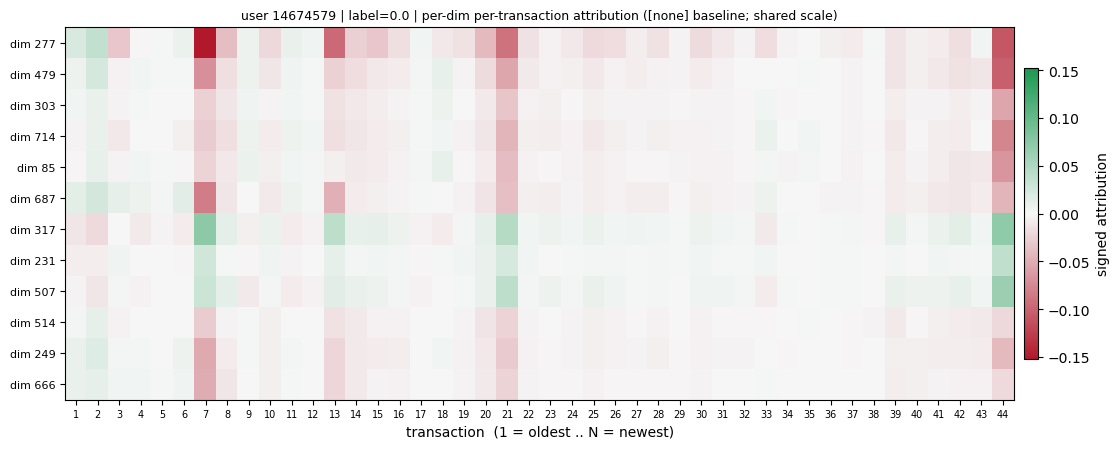

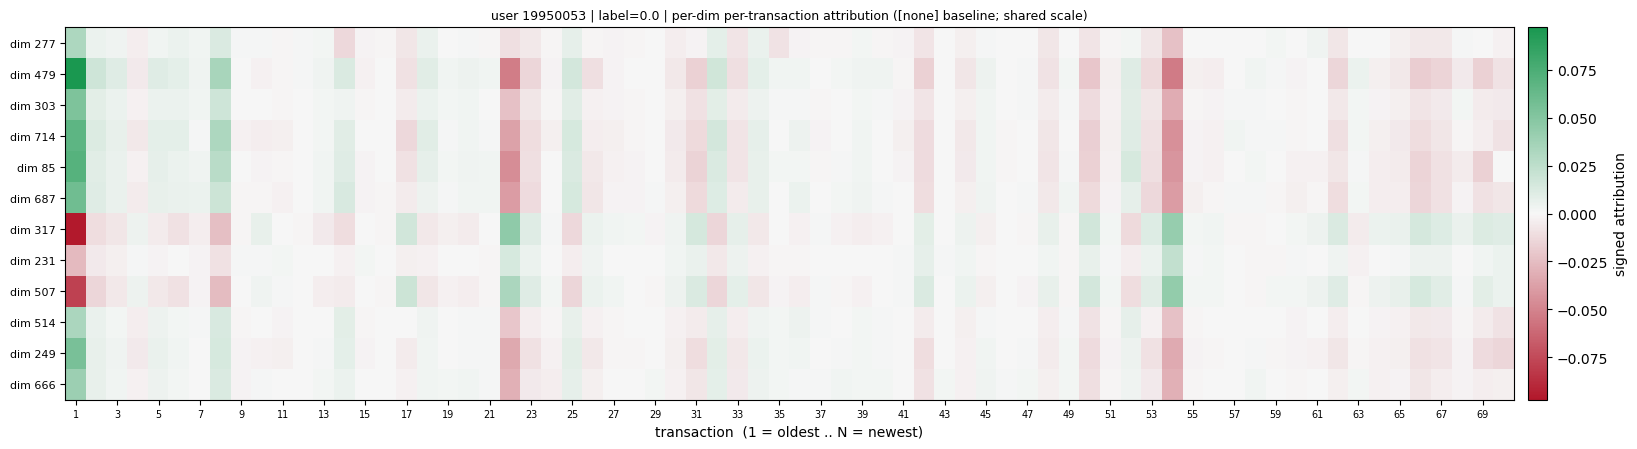

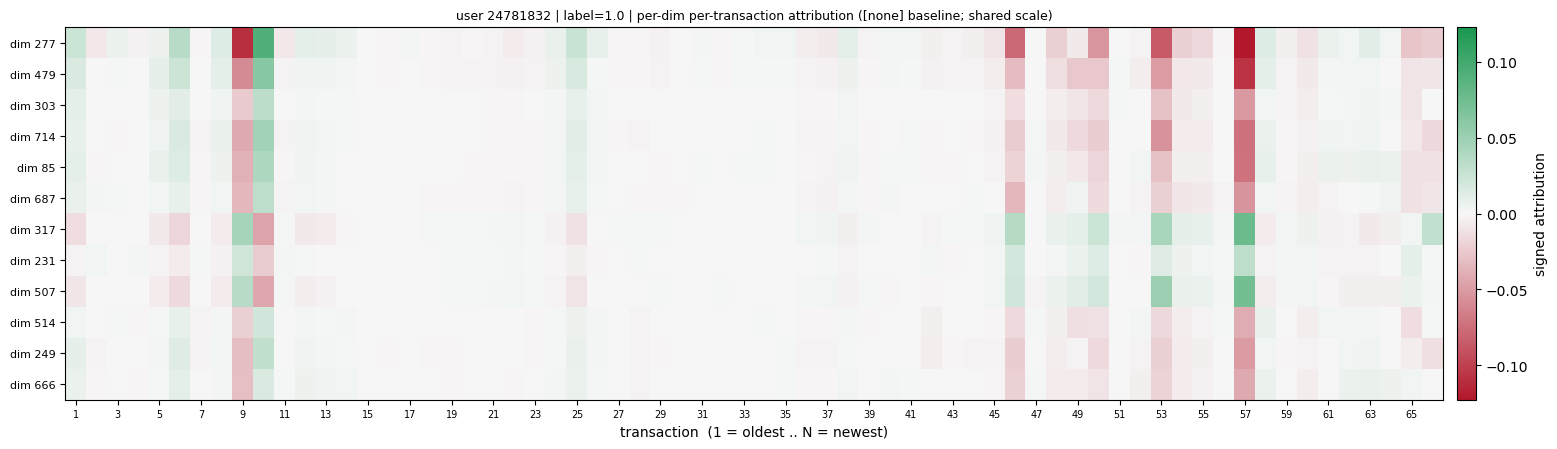

In [9]:
# === VIZ 1: per-dim x per-transaction attribution heatmap (12 dims x N txns), one figure per user ===
# Row = one of the 12 TOP_DIMS; column = one transaction; value = that transaction's attribution for that
# dim ([none] baseline from real_results; [bos]/[eos] excluded). Shows WHERE in the sequence each dim fires.
# Shared symmetric color scale across all rows (so a quiet dim reads quiet, honestly). Green=+, red=-.
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

RWG = LinearSegmentedColormap.from_list("red_white_green", ["#b2182b", "#f7f7f7", "#1a9850"])

def per_dim_txn_matrix(res, dims, attr_key="attr"):
    """(len(dims), n_txn) matrix of per-transaction attribution; [bos]/[eos] excluded from each txn sum."""
    tok, attr = res["token_ids"], res[attr_key]
    n = aggregate_tokens_to_transactions(attr[dims[0]]["per_token"], tok, TXN_SEP_ID)[0]["n"]
    M = np.zeros((len(dims), n))
    for r, d in enumerate(dims):
        for s in aggregate_tokens_to_transactions(attr[d]["per_token"], tok, TXN_SEP_ID, exclude_ids=BOS_EOS_IDS):
            M[r, s["idx"] - 1] = s["attr"]
    return M

for uid, res in real_results.items():
    M = per_dim_txn_matrix(res, TOP_DIMS)
    n = M.shape[1]; mx = float(np.abs(M).max()) or 1.0
    fig, ax = plt.subplots(figsize=(min(0.20 * n + 2.5, 22), 4.6))
    im = ax.imshow(M, cmap=RWG, norm=TwoSlopeNorm(vcenter=0.0, vmin=-mx, vmax=mx), aspect="auto")
    ax.set_yticks(range(len(TOP_DIMS))); ax.set_yticklabels([f"dim {d}" for d in TOP_DIMS], fontsize=8)
    step = max(1, n // 30)
    ax.set_xticks(range(0, n, step)); ax.set_xticklabels([str(i + 1) for i in range(0, n, step)], fontsize=7)
    ax.set_xlabel("transaction  (1 = oldest .. N = newest)")
    ax.set_title(f"user {uid} | label={res['label']} | per-dim per-transaction attribution "
                 f"([none] baseline; shared scale)", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label="signed attribution")
    plt.tight_layout(); plt.show()

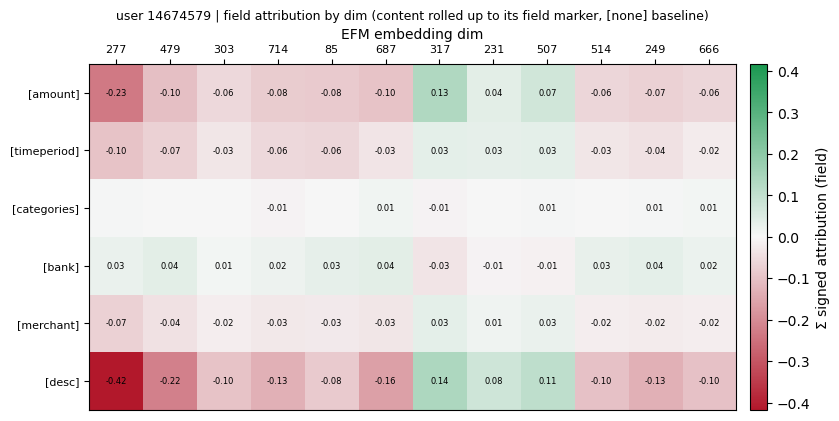

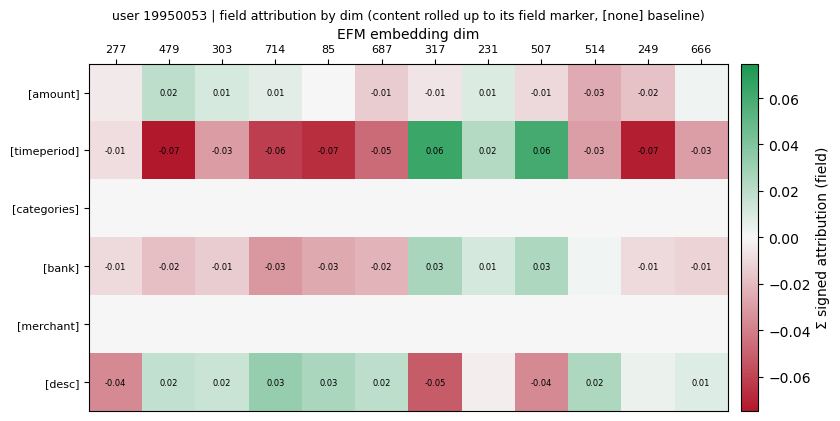

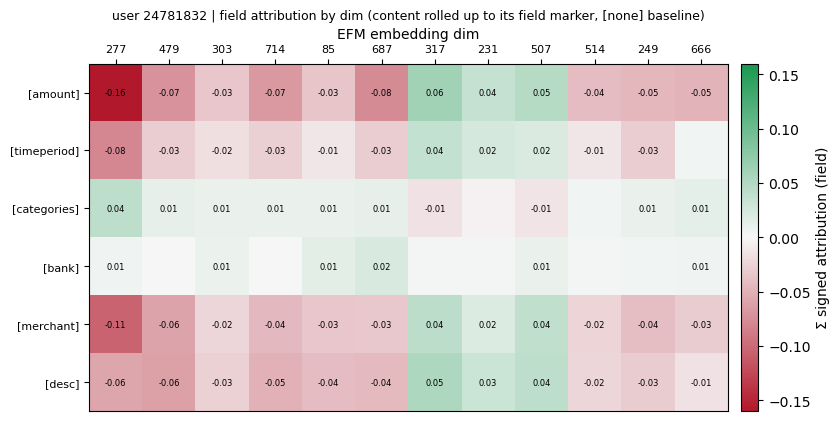

In [10]:
# === VIZ 2: structural-FIELD x embedding-dim attribution heatmap (1 per user), [none] baseline ===
# Keeps the [none] baseline (no switch to [eos]). Each structural marker becomes a FIELD BUCKET that
# absorbs the attribution of the NON-structural tokens that FOLLOW it, up to the next structural marker
# (the field's values describe it) — summed across ALL transactions. So:
#   [amount]<-[amt_sign_*]+[amt_bin_*], [timeperiod]<-[month_*]/[dom_*]/[weekday_*],
#   [categories]<-[cat_*], [bank]<-bank value, [merchant]<-merchant text, [desc]<-desc text.
# We compute the bucketing over ALL structural markers (so values are credited correctly) but only DISPLAY
# the content-field rows: [bos]/[eos]/[txn_sep] are seam/pool tokens and [txn_type]'s only value [type_*] is
# held fixed by the [none] baseline -> those rows are all ~0, so they're dropped for legibility. Green=+, red=-.
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
RWG = LinearSegmentedColormap.from_list("red_white_green", ["#b2182b", "#f7f7f7", "#1a9850"])
STRUCT_LIST = list(STRUCTURAL_TOKENS)
# Structurally-zero rows under [none] (dropped from display; still used as markers for correct bucketing):
DROP_FIELDS = {BOS_TOKEN, EOS_TOKEN, TXN_SEP_TOKEN, "[txn_type]"}
FIELD_ROWS  = [t for t in STRUCT_LIST if t not in DROP_FIELDS]
KEEP_IDX    = [STRUCT_LIST.index(t) for t in FIELD_ROWS]

def structural_field_matrix(token_ids, attr, struct_list, dims):
    """cell[s,d] = sum over non-structural tokens following marker s (its field values) of attr[d],
    accumulated across all of s's occurrences. Each non-structural token is credited to the most recent
    preceding structural marker."""
    row_of = {runtime.vocab[t]: r for r, t in enumerate(struct_list)}
    M = np.zeros((len(struct_list), len(dims)))
    for c, d in enumerate(dims):
        pt = attr[d]["per_token"]
        cur = None
        for i, t in enumerate(token_ids):
            if t in row_of:          # structural marker -> becomes the owning field for what follows
                cur = row_of[t]
            elif cur is not None:    # non-structural value -> credit to the owning field marker
                M[cur, c] += pt[i]
    return M

for uid, res in real_results.items():
    M = structural_field_matrix(res["token_ids"], res["attr"], STRUCT_LIST, TOP_DIMS)[KEEP_IDX]  # drop zero rows
    mx = float(np.abs(M).max()) or 1.0
    fig, ax = plt.subplots(figsize=(8.5, 0.42 * len(FIELD_ROWS) + 1.8))
    im = ax.imshow(M, cmap=RWG, norm=TwoSlopeNorm(vcenter=0.0, vmin=-mx, vmax=mx), aspect="auto")
    ax.set_xticks(range(len(TOP_DIMS))); ax.set_xticklabels([str(d) for d in TOP_DIMS], fontsize=8)
    ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
    ax.set_xlabel("EFM embedding dim")
    ax.set_yticks(range(len(FIELD_ROWS))); ax.set_yticklabels(FIELD_ROWS, fontsize=8)
    for r in range(M.shape[0]):
        for c in range(M.shape[1]):
            if abs(M[r, c]) > 0.005:
                ax.text(c, r, f"{M[r, c]:.2f}", ha="center", va="center", fontsize=6)
    ax.set_title(f"user {uid} | field attribution by dim "
                 f"(content rolled up to its field marker, [none] baseline)", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Σ signed attribution (field)")
    plt.tight_layout(); plt.show()

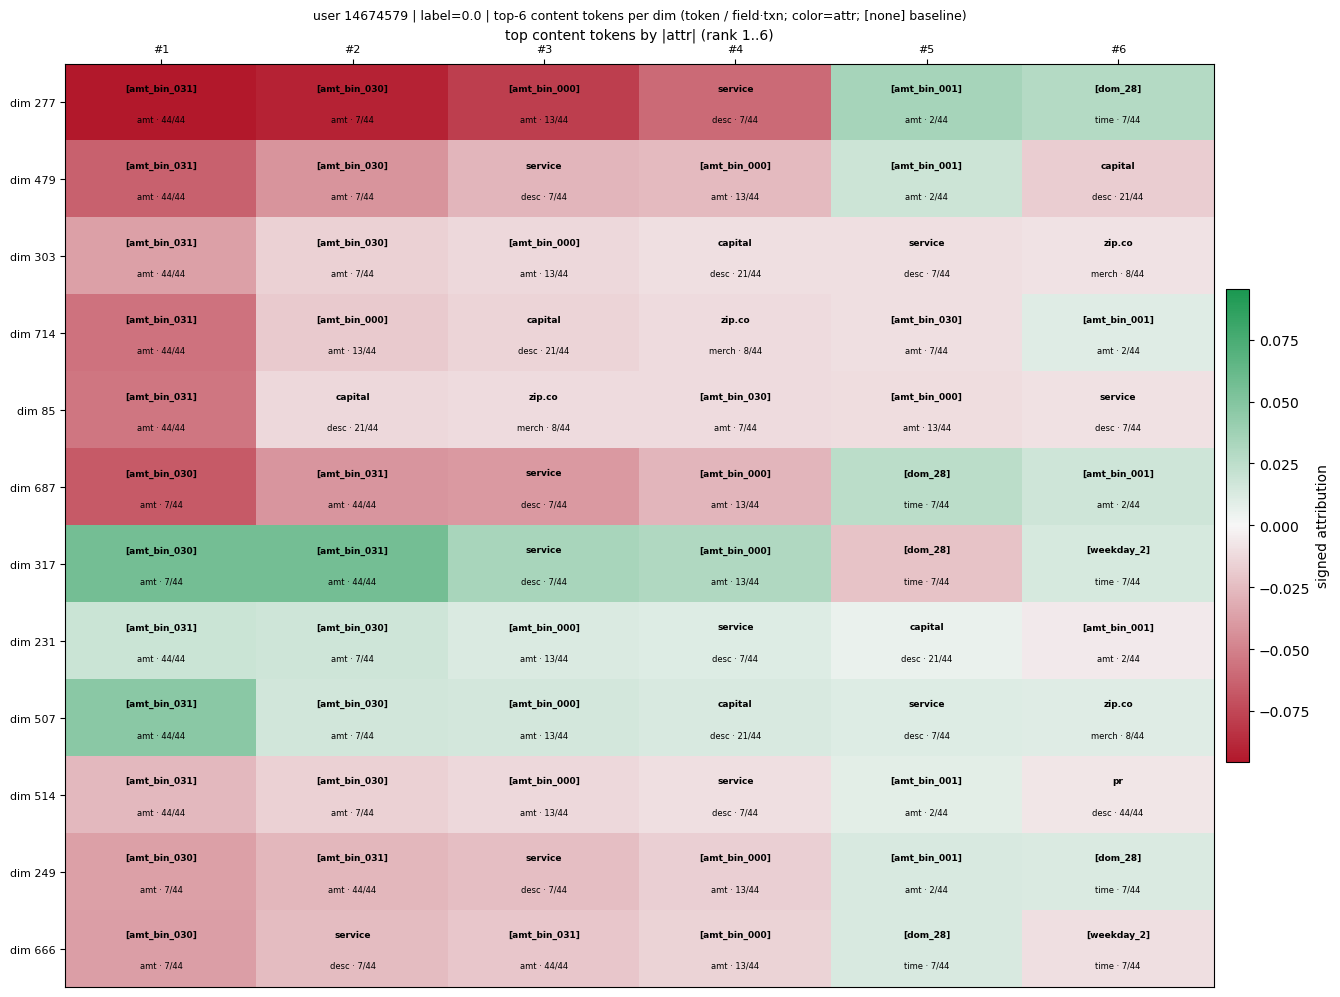

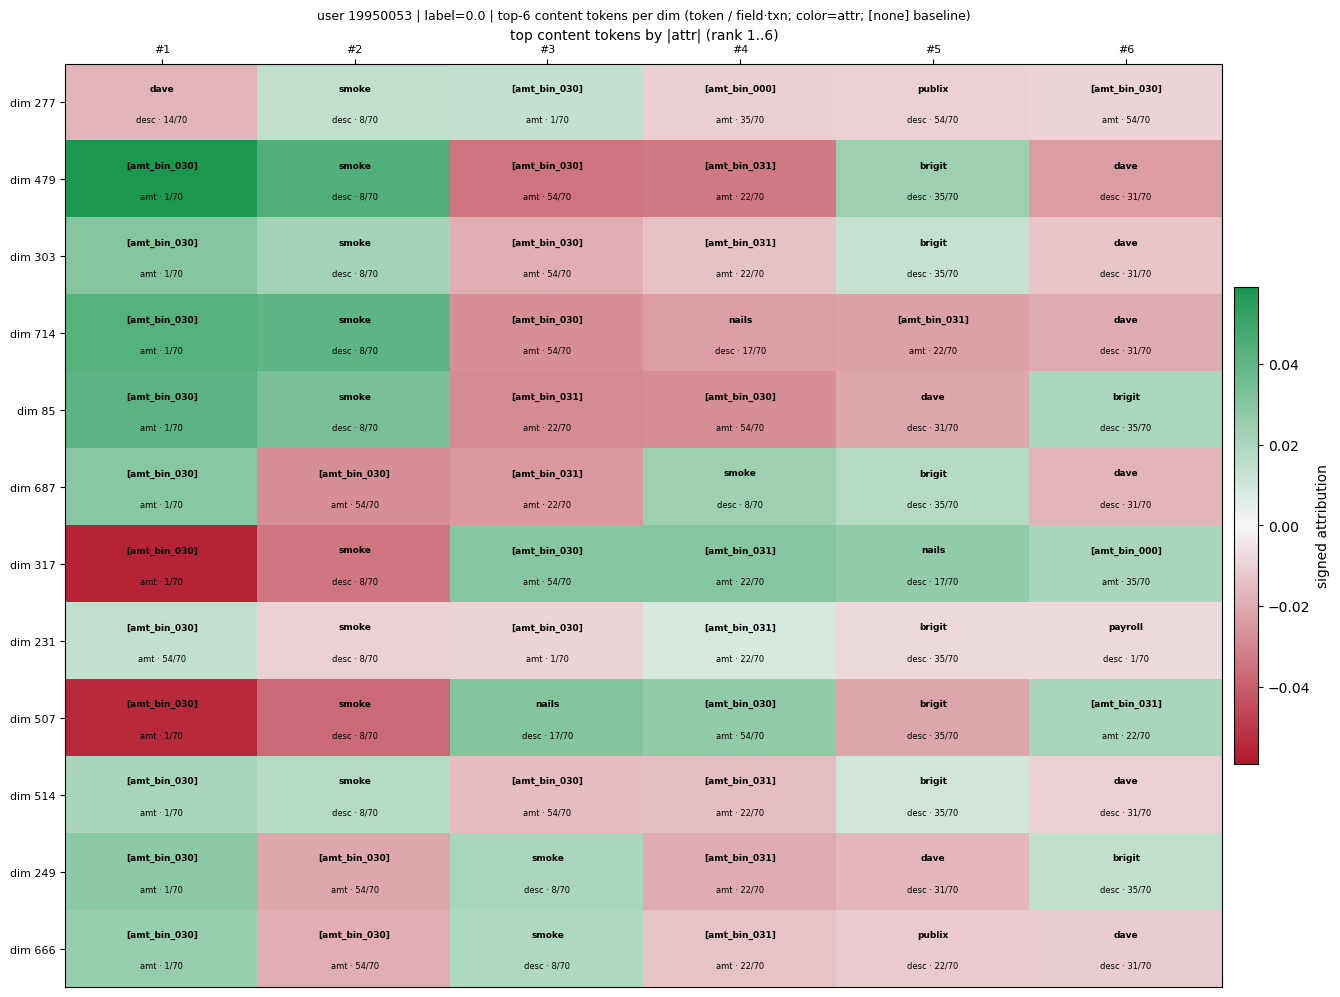

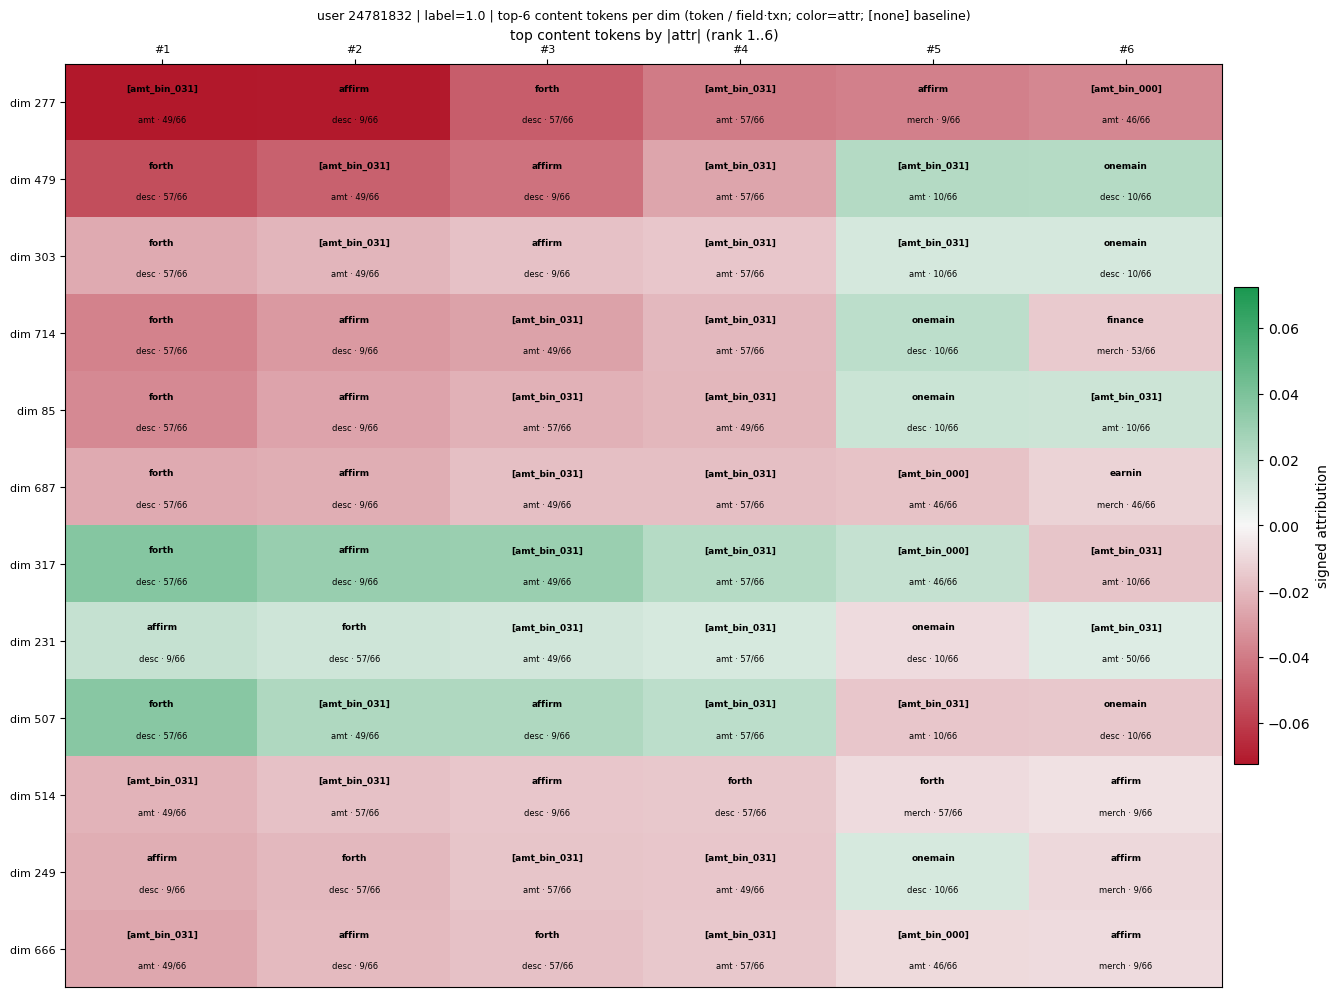

In [11]:
# === VIZ 3: top-content-token "reason-code" grid (12 dims x top-6 tokens), one per user ===
# Rows = the 12 TOP_DIMS; columns = that dim's top-6 NON-structural tokens by |attr| ([none] baseline).
# Each cell: line1 = token (truncated); line2 = "<field> · k/N" where field = the structural marker the
# token follows (positional; can differ from the token's own name under field-slot drift) and k/N = its
# transaction. Color = signed attribution (green=+, red=-, per-user symmetric scale). No printed number —
# color carries magnitude/sign.
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
RWG = LinearSegmentedColormap.from_list("red_white_green", ["#b2182b", "#f7f7f7", "#1a9850"])
SHORT_FIELD = {"[amount]": "amt", "[timeperiod]": "time", "[categories]": "cat", "[bank]": "bank",
               "[merchant]": "merch", "[desc]": "desc", "[txn_type]": "type",
               "[bos]": "bos", "[eos]": "eos", "[txn_sep]": "sep"}
K = 6

def _pos_field(token_ids, struct_ids, id2tok):
    """For each position, the structural marker it follows (most-recent preceding marker name)."""
    out, cur = {}, None
    for i, t in enumerate(token_ids):
        if t in struct_ids:
            cur = id2tok.get(t, "")
        out[i] = cur
    return out

def top_content_with_field(per_token, token_ids, struct_ids, txn_of_pos, pos_field, id2tok, k=K):
    out = []
    for i in np.argsort(-np.abs(per_token)):
        i = int(i)
        if token_ids[i] in struct_ids:
            continue
        out.append({"tok": id2tok.get(token_ids[i], str(token_ids[i])), "attr": float(per_token[i]),
                    "txn": txn_of_pos[i], "field": pos_field[i]})
        if len(out) >= k:
            break
    return out

for uid, res in real_results.items():
    tok_ids, attr = res["token_ids"], res["attr"]
    bounds, N = _txn_bounds(tok_ids, TXN_SEP_ID)
    txn_of_pos = {i: k + 1 for k, (a, b) in enumerate(zip(bounds[:-1], bounds[1:])) for i in range(a, b)}
    pos_field = _pos_field(tok_ids, STRUCT_IDS, id2tok)
    A = np.full((len(TOP_DIMS), K), np.nan); cells = [[None] * K for _ in TOP_DIMS]
    for r, d in enumerate(TOP_DIMS):
        for c, it in enumerate(top_content_with_field(attr[d]["per_token"], tok_ids, STRUCT_IDS,
                                                       txn_of_pos, pos_field, id2tok, k=K)):
            A[r, c] = it["attr"]; cells[r][c] = it
    mx = float(np.nanmax(np.abs(A))) or 1.0
    cmap = RWG.copy(); cmap.set_bad("#f0f0f0")
    fig, ax = plt.subplots(figsize=(13.5, 0.74 * len(TOP_DIMS) + 1.2))
    im = ax.imshow(np.ma.masked_invalid(A), cmap=cmap, norm=TwoSlopeNorm(0.0, -mx, mx), aspect="auto")
    ax.set_yticks(range(len(TOP_DIMS))); ax.set_yticklabels([f"dim {d}" for d in TOP_DIMS], fontsize=8)
    ax.set_xticks(range(K)); ax.set_xticklabels([f"#{i+1}" for i in range(K)], fontsize=8)
    ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
    ax.set_xlabel("top content tokens by |attr| (rank 1..6)")
    for r in range(len(TOP_DIMS)):
        for c in range(K):
            it = cells[r][c]
            if it is None:
                continue
            tk = it["tok"]; tk = tk[:15] + "…" if len(tk) > 16 else tk
            fld = SHORT_FIELD.get(it["field"], (it["field"] or "?").strip("[]")[:5])
            ax.text(c, r - 0.18, tk, ha="center", va="center", fontsize=6.5, weight="bold")
            ax.text(c, r + 0.22, f"{fld} · {it['txn']}/{N}", ha="center", va="center", fontsize=6)
    ax.set_title(f"user {uid} | label={res['label']} | top-{K} content tokens per dim "
                 f"(token / field·txn; color=attr; [none] baseline)", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="signed attribution")
    plt.tight_layout(); plt.show()

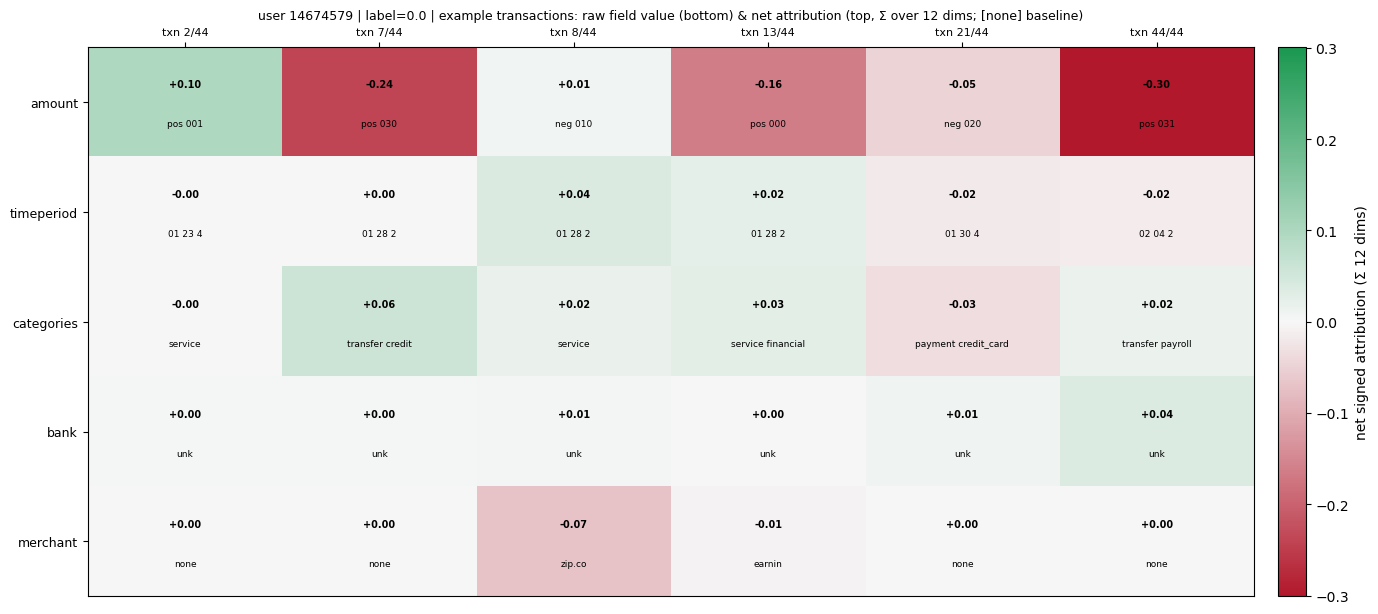

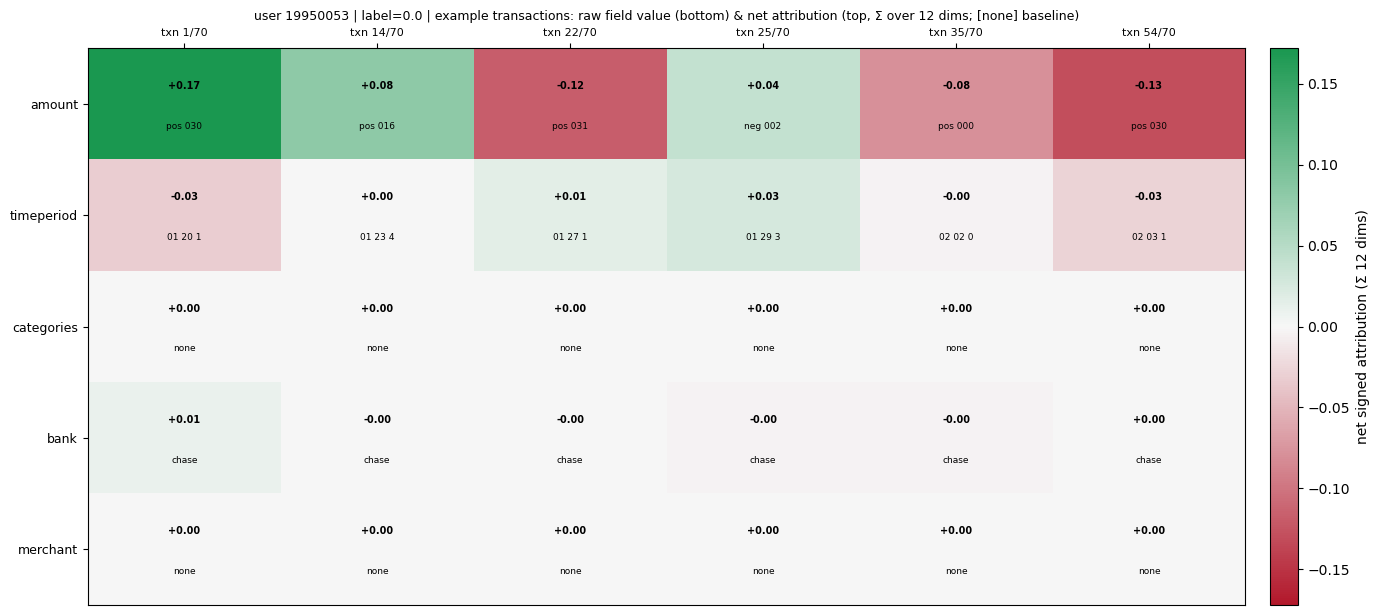

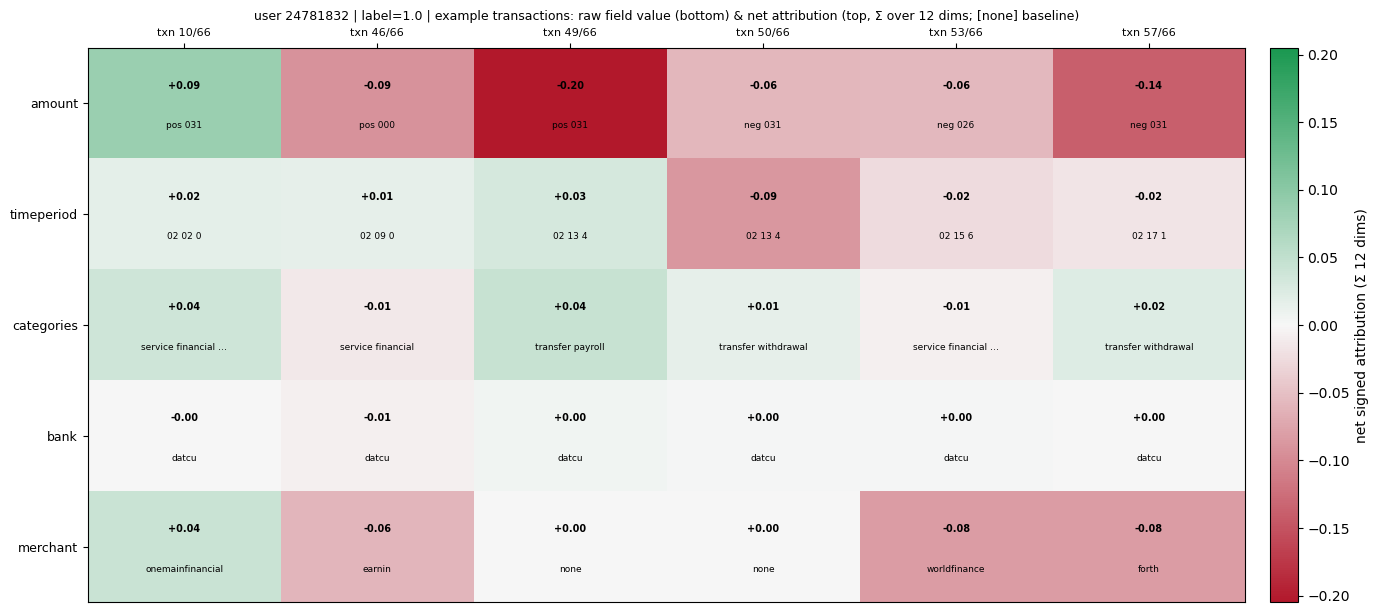

In [12]:
# === VIZ 4: example transactions — raw field VALUES and their attribution (1 per user) ===
# Joe's ask: see how the ACTUAL raw values (amount bin, category, bank, merchant, time) move the score.
# Layout like VIZ 2, but: rows = content fields; columns = a few EXAMPLE transactions (the top-N by total
# |attr| across these fields, shown chronologically). Each cell shows the net attribution (top) over the 12
# SHAP-top dims and the RAW VALUE (bottom, truncated with …). Color = net signed attribution (green=+, red=-,
# per-user symmetric). Values are credited to the most-recent field marker (positional, like VIZ 2), [none]
# baseline. EXCEPTION: the [amount] row is restricted to its own [amt_sign_*]/[amt_bin_*] tokens so slot-drift
# [type_*] tokens don't leak in (amount shows sign + binned amount only). NOTE: "net" is the UNWEIGHTED sum
# over the 12 dims; true risk impact would weight each dim by its per-user SHAP value (Stage 3). Because dims
# are entangled (VIZ 3), a near-zero net can still hide large opposing per-dim effects — read with VIZ 1/2.
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
RWG = LinearSegmentedColormap.from_list("red_white_green", ["#b2182b", "#f7f7f7", "#1a9850"])

VIZ4_FIELDS = ["[amount]", "[timeperiod]", "[categories]", "[bank]", "[merchant]"]
N_EX = 6
_STRIP = ("amt_sign_", "amt_bin_", "cat_", "bank_name_", "bank_", "month_", "dom_", "weekday_", "type_")

def _field_accepts(field, name):
    """Which value tokens belong to a field. [amount] is restricted to its sign/bin tokens so positional
    slot-drift can't leak a [type_*] (or other) token into the amount row; other fields take all values."""
    if field == "[amount]":
        return name.startswith("[amt_")
    return True

def _raw_value(field, names, maxlen=18):
    """Readable raw value from the value-token NAMES under a field marker."""
    if field in ("[merchant]", "[desc]"):                              # free-text subwords -> reconstruct
        txt = "".join(n.strip("[]").replace("##", "") for n in names).replace("▁", " ").strip()
    else:                                                              # categorical/binned -> strip prefixes
        parts = []
        for n in names:
            s = n.strip("[]")
            for pre in _STRIP:
                if s.startswith(pre):
                    s = s[len(pre):]; break
            parts.append(s)
        txt = " ".join(parts)
    txt = txt or "—"
    return txt[:maxlen] + "…" if len(txt) > maxlen + 1 else txt

def example_txn_fields(token_ids, attr, dims, struct_ids, id2tok, fields, n_ex=N_EX):
    """Per (transaction, field): net signed attr (Σ dims), magnitude (Σ|dims|), and value-token names.
    Returns (cells, example_txns chronological, N)."""
    bounds, N = _txn_bounds(token_ids, TXN_SEP_ID)
    txn_of_pos = {i: k + 1 for k, (a, b) in enumerate(zip(bounds[:-1], bounds[1:])) for i in range(a, b)}
    net = np.zeros(len(token_ids)); mag = np.zeros(len(token_ids))
    for d in dims:
        pt = attr[d]["per_token"]; net += pt; mag += np.abs(pt)
    cells, cur = {}, None
    for i, t in enumerate(token_ids):
        nm = id2tok.get(t, str(t))
        if t in struct_ids:
            cur = nm                                                   # current owning field marker
        elif cur in fields and _field_accepts(cur, nm):
            c = cells.setdefault((txn_of_pos[i], cur), {"signed": 0.0, "mag": 0.0, "names": []})
            c["signed"] += net[i]; c["mag"] += mag[i]; c["names"].append(nm)
    txn_mag = {}
    for (txn, _fld), c in cells.items():
        txn_mag[txn] = txn_mag.get(txn, 0.0) + c["mag"]
    ex = sorted(sorted(txn_mag, key=txn_mag.get, reverse=True)[:n_ex])  # top-N by |attr|, then chronological
    return cells, ex, N

for uid, res in real_results.items():
    cells, ex, N = example_txn_fields(res["token_ids"], res["attr"], TOP_DIMS, STRUCT_IDS, id2tok, VIZ4_FIELDS)
    R, C = len(VIZ4_FIELDS), len(ex)
    if C == 0:
        print(f"user {uid}: no example transactions to show"); continue
    A = np.full((R, C), np.nan); val = [[None] * C for _ in range(R)]
    for r, fld in enumerate(VIZ4_FIELDS):
        for c, txn in enumerate(ex):
            cell = cells.get((txn, fld))
            if cell is None:
                continue
            A[r, c] = cell["signed"]; val[r][c] = _raw_value(fld, cell["names"])
    mx = float(np.nanmax(np.abs(A))) if np.isfinite(A).any() else 1.0
    cmap = RWG.copy(); cmap.set_bad("#f0f0f0")
    fig, ax = plt.subplots(figsize=(1.9 * C + 2.5, 0.95 * R + 1.5))
    im = ax.imshow(np.ma.masked_invalid(A), cmap=cmap, norm=TwoSlopeNorm(0.0, -mx, mx), aspect="auto")
    ax.set_yticks(range(R)); ax.set_yticklabels([f.strip("[]") for f in VIZ4_FIELDS], fontsize=9)
    ax.set_xticks(range(C)); ax.set_xticklabels([f"txn {t}/{N}" for t in ex], fontsize=8)
    ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
    for r in range(R):
        for c in range(C):
            if val[r][c] is None:
                continue
            ax.text(c, r - 0.16, f"{A[r, c]:+.2f}", ha="center", va="center", fontsize=7, weight="bold")
            ax.text(c, r + 0.20, val[r][c], ha="center", va="center", fontsize=6.5)
    ax.set_title(f"user {uid} | label={res['label']} | example transactions: raw field value (bottom) & net "
                 f"attribution (top, Σ over 12 dims; [none] baseline)", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="net signed attribution (Σ 12 dims)")
    plt.tight_layout(); plt.show()


In [13]:
# === VIZ 5: dim-277 token-level attribution per transaction (Captum visualize_text) ===
# Joe's ask: individual-record view of how raw transaction data drives a single dim. For DIM_FOCUS (277),
# per user we take the top-10 transactions by TOTAL attribution to that dim (Σ|per-token attr|, i.e. how
# strongly 277 engages the transaction regardless of sign) and render each token inline, highlighted
# green(+)/red(-) by its SIGNED attribution to the dim (deeper = stronger). Mirrors Captum's word-importance
# table. [none] baseline => structural/held-fixed tokens (~0) render ~white. Color is normalized PER USER
# (deepest = that user's strongest token).
#
# Ranking & score = Σ|attr| (TOTAL, L1): measures how strongly 277 engages the transaction's content. The
# signed net sum can cancel to ~0 even when tokens are active, so for a "what does 277 react to" view we
# rank/score by magnitude (token colors still carry the +/- direction). Magnitude varies a lot by user: for a
# user where 277 is a minor driver, even the top-10 will be small.
#
# RAW-VALUE MAPPING (Joe): numeric/binned tokens are shown as their pre-tokenization values --
#   [amt_bin_NNN] -> dollar RANGE from interface_config["amount_bin_edges_cents"] (exact pre-bin amount is NOT
#   in this bake -- amount_cents masked -- and the model only saw the bin, so the range is the faithful raw
#   value); [month_MM]/[dom_DD]/[weekday_W] -> Jan../day/Mon.. (weekday 0=Mon); [amt_sign_*] -> -/+;
#   cat_*/bank_name_*/bank_*/type_* -> prefix stripped; merchant subwords as-is (pypl). Structural field
#   markers keep their brackets so each reads "[field] value".
from captum.attr import visualization as viz
from IPython.display import HTML, display

DIM_FOCUS = 277
TOP_TXN   = 10
_EDGES  = runtime.interface_config["amount_bin_edges_cents"]
_MONTHS = ["", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
_WDAYS  = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]      # dt.weekday(): 0=Mon .. 6=Sun
_VAL_PREFIXES = ("cat_", "bank_name_", "bank_", "type_")          # bank_name_ before bank_ (longest first)

def _money(cents):
    d = cents / 100.0
    if d >= 1000: return f"${d/1000:.0f}k"
    if d >= 10:   return f"${d:.0f}"
    return ("$%.2f" % d).rstrip("0").rstrip(".")

def _raw_token(name, is_struct):
    """Structural field markers keep brackets; value tokens render bare (numerics -> raw values)."""
    if is_struct:
        return name                                              # keep brackets: [amount], [merchant], ...
    s = name[1:-1] if len(name) > 1 and name.startswith("[") and name.endswith("]") else name
    if s.startswith("amt_bin_"):
        tail = s[len("amt_bin_"):]
        if tail.isdigit() and 0 <= int(tail) < len(_EDGES) - 1:
            lo, hi = _EDGES[int(tail)], _EDGES[int(tail) + 1]
            return f"≥{_money(lo)}" if hi >= 1e12 else f"{_money(lo)}–{_money(hi)}"
        return s.replace("amt_bin_", "amt:")                     # underflow / overflow
    if s.startswith("amt_sign_"):
        return "−" if s.endswith("neg") else "+"
    if s.startswith("month_"):
        t = s[len("month_"):];   return _MONTHS[int(t)] if t.isdigit() and 0 < int(t) < 13 else s
    if s.startswith("dom_"):
        t = s[len("dom_"):];     return t.lstrip("0") if t.isdigit() else s
    if s.startswith("weekday_"):
        t = s[len("weekday_"):]; return _WDAYS[int(t)] if t.isdigit() and int(t) < 7 else s
    for pre in _VAL_PREFIXES:
        if s.startswith(pre):    return s[len(pre):] or s        # cat_groceries->groceries, bank_unk->unk
    return s

for uid, res in real_results.items():
    tok_ids = res["token_ids"]; pt = res["attr"][DIM_FOCUS]["per_token"]; cd = res["attr"][DIM_FOCUS]["conv_delta"]
    bounds, N = _txn_bounds(tok_ids, TXN_SEP_ID)
    spans = list(zip(bounds[:-1], bounds[1:]))
    order = sorted(range(N), key=lambda k: -float(np.abs(pt[spans[k][0]:spans[k][1]]).sum()))[:TOP_TXN]  # L1
    top   = sorted(order)                                                  # chronological (beginning -> end)
    scale = max((float(np.abs(pt[spans[k][0]:spans[k][1]]).max()) for k in top), default=1.0) or 1.0
    total_abs = float(np.abs(pt).sum()) or 1.0
    records = []
    for k in top:
        a, b = spans[k]
        wa   = torch.tensor(pt[a:b] / scale, dtype=torch.float)            # normalized to ~[-1,1] for color
        toks = [_raw_token(id2tok.get(t, str(t)), t in STRUCT_IDS) for t in tok_ids[a:b]]
        records.append(viz.VisualizationDataRecord(
            word_attributions=wa,
            pred_prob=round(float(np.abs(pt[a:b]).sum()) / total_abs, 3),  # share of |dim attr| from this txn
            pred_class=f"txn {k + 1}/{N}",
            true_class=f"user {uid} (L{int(res['label'])})",
            attr_class=f"dim {DIM_FOCUS}",
            attr_score=round(float(np.abs(pt[a:b]).sum()), 4),             # TOTAL |attr| over the txn (L1)
            raw_input_ids=toks,
            convergence_score=round(cd, 4),
        ))
    display(HTML(f"<h3 style='font-family:monospace;margin-top:18px'>user {uid} | label={res['label']} | "
                 f"dim {DIM_FOCUS} — top-{TOP_TXN} transactions by total |attribution| "
                 f"(token color = signed attr to dim {DIM_FOCUS}: green +, red −; per-user scale)</h3>"))
    viz.visualize_text(records)   # auto-displays the HTML table (one per user)


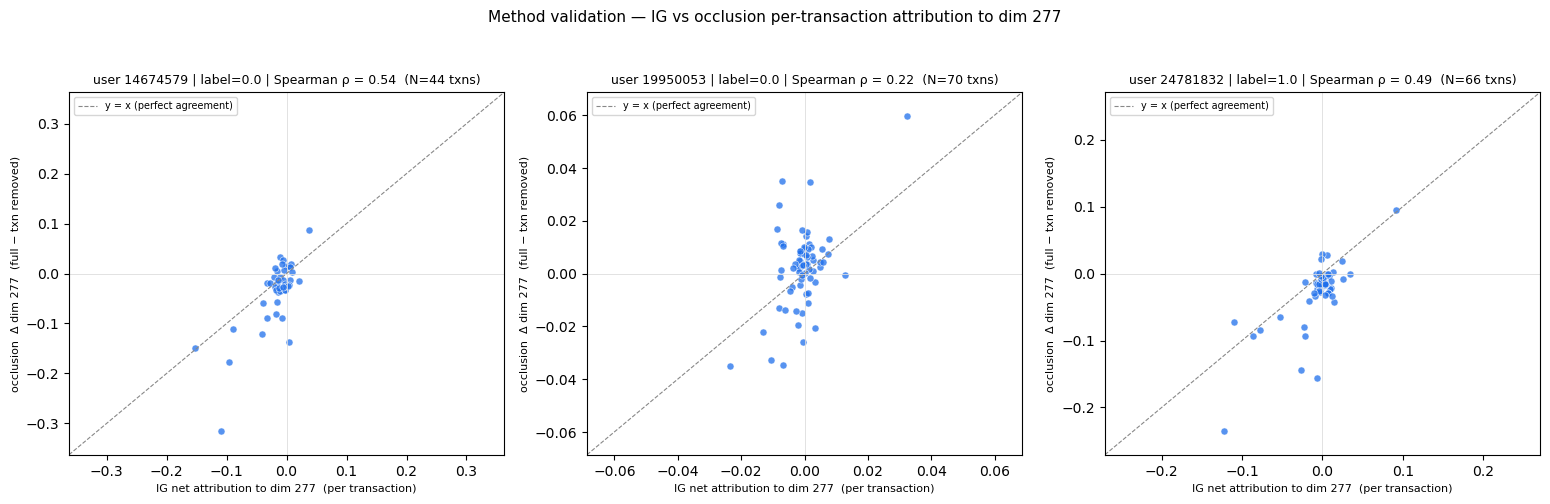

Spearman ρ (IG vs occlusion) per user: {'14674579': 0.537, '19950053': 0.217, '24781832': 0.488}


In [14]:
# === VIZ 6 (validation): IG vs occlusion cross-check for dim 277 ===
# Trust check on the dim-277 attributions before scaling. IG is gradient-based; occlusion is a direct
# counterfactual, so agreement = method-robust. OCCLUSION = leave-one-transaction-out toward the SAME [none]
# baseline IG uses: for each transaction, replace just its tokens with their make_baseline([none]) values,
# re-run the model, and measure Δ dim-277 = full - occluded (signed: +ve => that txn pushes 277 up). We then
# scatter, per transaction, IG's net attribution to 277 (Σ per-token attr over the txn) vs that occlusion Δ,
# one panel per user, with Spearman ρ. Tight diagonal + high ρ => trust IG; off-diagonal points = where the
# gradient story and the counterfactual disagree. Cheap: one forward (no grad) per transaction.
import matplotlib.pyplot as plt

DIM_CHK = 277

def _rankdata(a):
    a = np.asarray(a, float); order = np.argsort(a, kind="mergesort")
    ranks = np.empty(len(a)); ranks[order] = np.arange(1, len(a) + 1)
    sa = a[order]; i = 0                                          # average tied ranks
    while i < len(a):
        j = i
        while j + 1 < len(a) and sa[j + 1] == sa[i]:
            j += 1
        if j > i:
            ranks[order[i:j + 1]] = (i + 1 + j + 1) / 2.0
        i = j + 1
    return ranks

def _spearman(x, y):
    rx, ry = _rankdata(x), _rankdata(y); rx = rx - rx.mean(); ry = ry - ry.mean()
    d = np.sqrt((rx ** 2).sum() * (ry ** 2).sum())
    return float((rx * ry).sum() / d) if d > 0 else float("nan")

def _emb_dim(token_ids, dim):
    ids, cu, pos, T = build_user_pack(token_ids)
    with torch.no_grad():
        e = embedding_forward(ids, cu, pos, T)
    return float(e[0, dim])

def occlusion_txn(token_ids, dim):
    """Leave-one-transaction-out toward the [none] baseline. Returns (spans, deltas, N)."""
    bounds, N = _txn_bounds(token_ids, TXN_SEP_ID)
    spans = list(zip(bounds[:-1], bounds[1:]))
    base  = make_baseline(token_ids, runtime, kind=BASELINE).view(-1).tolist()   # [none] version per position
    full  = _emb_dim(token_ids, dim)
    deltas = []
    for a, b in spans:
        occ = list(token_ids); occ[a:b] = base[a:b]              # null just this transaction's content
        deltas.append(full - _emb_dim(occ, dim))
    return spans, deltas, N

n = len(real_results)
fig, axes = plt.subplots(1, n, figsize=(5.2 * n, 4.8))
if n == 1:
    axes = [axes]
rhos = {}
for ax, (uid, res) in zip(axes, real_results.items()):
    pt = res["attr"][DIM_CHK]["per_token"]
    spans, occ, N = occlusion_txn(res["token_ids"], DIM_CHK)     # one occlusion sweep per user
    ig = [float(pt[a:b].sum()) for a, b in spans]                # IG net attribution per transaction
    rho = _spearman(ig, occ); rhos[uid] = round(rho, 3)
    lim = max(float(np.max(np.abs(ig))) if ig else 1e-6, float(np.max(np.abs(occ))) if occ else 1e-6) * 1.15
    ax.axhline(0, color="#ddd", lw=.6); ax.axvline(0, color="#ddd", lw=.6)
    ax.plot([-lim, lim], [-lim, lim], "--", color="#888", lw=.8, label="y = x (perfect agreement)")
    ax.scatter(ig, occ, s=26, color="#1f6feb", alpha=.75, edgecolor="white", linewidth=.5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(f"IG net attribution to dim {DIM_CHK}  (per transaction)", fontsize=8)
    ax.set_ylabel(f"occlusion  Δ dim {DIM_CHK}  (full − txn removed)", fontsize=8)
    ax.set_title(f"user {uid} | label={res['label']} | Spearman ρ = {rho:.2f}  (N={N} txns)", fontsize=9)
    ax.legend(fontsize=7, loc="upper left")
fig.suptitle("Method validation — IG vs occlusion per-transaction attribution to dim 277", fontsize=11, y=1.04)
plt.tight_layout(); plt.show()
print("Spearman ρ (IG vs occlusion) per user:", rhos)


## Stage 3 — compose IG × SHAP  →  token → risk  (per user, optional)
token effect on the risk score = Σ_dims ( IG[token→dim] × SHAP[dim→risk for this user] ).
Per-user SHAP comes from the inference log keyed by (userid, predtime) — pull via the connector if needed.

In [15]:
# === Stage 3 — compose IG × SHAP  →  token → RISK  (per user) ===
# Stage 2 gives IG[token→emb_dim]; Stage 1 gives SHAP[emb_dim→risk]. Compose per user:
#   risk contribution of a token = Σ_dims ( IG[token→dim] × SHAP[dim→risk for this user] ),
# summed over the 12 TOP_DIMS we traced. This turns the dim-level story into a RISK-DIRECTION story:
# green = the token pushes THIS user's risk score UP, red = DOWN  (sign = IG sign × SHAP sign).
#
# CAVEAT (SHAP sourcing): per-user SHAP is pulled from the production inference log
# (main_prod.ml_data.efm_ppma_v1_inference_log -> response.shap_values.decoder39k_ppma_lora_emb_<d>).
# That log retains only ~recent weeks, so the Feb pred_times these IG runs use are no longer present;
# we use each user's MEAN SHAP over its available (Jun 2026) rows as a stable proxy. Defensible because
# (a) per-user SHAP is empirically stable & sign-coherent across dates, and (b) Stage 1 picked TOP_DIMS
# from this same recent-SHAP basis -- so IG×SHAP here is consistent with how the dims were chosen.
# This is a top-K (12-dim) APPROXIMATION of token->risk, not the full 768-dim composition (the other
# ~756 dims carry little |SHAP| by construction). Governed data: keep these SHAP values in this space.
#
# (Earlier caveat retained:) TOP_DIMS are RAW embedding dims (polysemantic) -- expect messy, multi-concept
# backtraces; that's the signal an SAE (monosemantic features) is the right next step (see methods-draft.md).

# Per-user SHAP[dim->risk], mean over available inference-log rows (rounded 4dp); keys = TOP_DIMS.
USER_SHAP = {
    14674579: {277:-0.1742, 479:-0.1286, 303:-0.0824, 714:-0.0991, 85:-0.0457, 687:-0.0913,
               317:-0.0594, 231:-0.0550, 507:-0.0450, 514:-0.0421, 249:-0.0350, 666: 0.0088},
    19950053: {277: 0.2306, 479: 0.3197, 303: 0.3162, 714: 0.3094, 85: 0.3061, 687: 0.1572,
               317: 0.2156, 231: 0.0519, 507: 0.0877, 514: 0.0545, 249: 0.0891, 666: 0.0415},
    24781832: {277: 0.2538, 479: 0.1655, 303: 0.1199, 714: 0.0544, 85:-0.0459, 687: 0.1539,
               317: 0.0701, 231: 0.0456, 507: 0.0689, 514: 0.0577, 249: 0.0530, 666: 0.0413},
}
S3_TOP_TXN = 10

def _risk_per_token(uid, res):
    """token->risk vector: Sum_d IG[token->d] * SHAP[d->risk for uid], over the 12 TOP_DIMS."""
    shap = np.array([USER_SHAP[uid][d] for d in TOP_DIMS], dtype=float)        # (12,)
    P    = np.stack([res["attr"][d]["per_token"] for d in TOP_DIMS], axis=0)   # (12, T)
    return (shap[:, None] * P).sum(0), shap, P                                 # (T,), (12,), (12,T)

for uid, res in real_results.items():
    su = int(uid)                                  # real_results keys are STRING uids; USER_SHAP is int-keyed
    if su not in USER_SHAP:
        print(f"user {uid}: no SHAP pulled -- skipping"); continue
    tok_ids = res["token_ids"]
    risk, shap, P = _risk_per_token(su, res)
    bounds, N = _txn_bounds(tok_ids, TXN_SEP_ID)
    spans = list(zip(bounds[:-1], bounds[1:]))

    # ---- per-dim risk story: signed net contribution of each dim = SHAP[d] * Sum_tokens IG[token->d] ----
    dim_net = {d: float(shap[i] * P[i].sum()) for i, d in enumerate(TOP_DIMS)}
    tot_net = sum(dim_net.values())
    top_dims = sorted(TOP_DIMS, key=lambda d: -abs(dim_net[d]))[:5]
    print(f"\nuser {uid} | label={res['label']} | Sigma(12-dim) risk-logit contribution = {tot_net:+.4f}")
    print("   dims driving risk (SHAP x SumIG):",
          ", ".join(f"d{d} {dim_net[d]:+.3f}" for d in top_dims))

    # ---- top content tokens by |risk contribution| (named entities / raw values) ----
    cont = [(i, float(risk[i])) for i in range(len(tok_ids))
            if tok_ids[i] not in STRUCT_IDS and tok_ids[i] not in BOS_EOS_IDS]
    cont.sort(key=lambda x: -abs(x[1]))
    print("   top tokens -> risk:",
          ", ".join(f"{_raw_token(id2tok.get(tok_ids[i], str(tok_ids[i])), False)}({v:+.3f})"
                    for i, v in cont[:8]))

    # ---- token-level highlight: top transactions by total |risk contribution| ----
    order = sorted(range(N), key=lambda k: -float(np.abs(risk[spans[k][0]:spans[k][1]]).sum()))[:S3_TOP_TXN]
    top   = sorted(order)                                                      # chronological
    scale = max((float(np.abs(risk[spans[k][0]:spans[k][1]]).max()) for k in top), default=1.0) or 1.0
    total_abs = float(np.abs(risk).sum()) or 1.0
    records = []
    for k in top:
        a, b = spans[k]
        wa   = torch.tensor(risk[a:b] / scale, dtype=torch.float)              # per-user normalized for color
        toks = [_raw_token(id2tok.get(t, str(t)), t in STRUCT_IDS) for t in tok_ids[a:b]]
        records.append(viz.VisualizationDataRecord(
            word_attributions=wa,
            pred_prob=round(float(np.abs(risk[a:b]).sum()) / total_abs, 3),    # share of |risk attr| from txn
            pred_class=f"txn {k + 1}/{N}",
            true_class=f"user {uid} (L{int(res['label'])})",
            attr_class="-> risk",
            attr_score=round(float(risk[a:b].sum()), 4),                       # SIGNED net risk contribution
            raw_input_ids=toks,
            convergence_score=round(tot_net, 4),
        ))
    display(HTML(f"<h3 style='font-family:monospace;margin-top:18px'>user {uid} | label={res['label']} | "
                 f"Stage 3: token &rarr; RISK (&Sigma; 12 dims &times; per-user SHAP) &mdash; top-{S3_TOP_TXN} "
                 f"transactions by |risk contribution| (green = raises risk, red = lowers; per-user scale)</h3>"))
    viz.visualize_text(records)

print("\nStage 3 complete: token->risk = Sum_d IG[token->d]*SHAP[d->risk], 12 TOP_DIMS, recent-SHAP proxy.")



user 14674579 | label=0.0 | Sigma(12-dim) risk-logit contribution = +0.2444
   dims driving risk (SHAP x SumIG): d277 +0.137, d479 +0.050, d714 +0.029, d687 +0.025, d317 -0.018
   top tokens -> risk: ≥$699(+0.035), $331–$699(+0.027), $0–$1(+0.021), service(+0.018), $1–$2.25(-0.011), 28(-0.009), capital(+0.009), earnin(+0.008)



user 19950053 | label=0.0 | Sigma(12-dim) risk-logit contribution = -0.0840
   dims driving risk (SHAP x SumIG): d85 -0.021, d479 -0.018, d714 -0.017, d277 -0.014, d687 -0.010
   top tokens -> risk: $331–$699(+0.050), smoke(+0.044), $331–$699(-0.034), ≥$699(-0.030), dave(-0.025), brigit(+0.023), $25–$27(+0.022), $0–$1(-0.022)



user 24781832 | label=1.0 | Sigma(12-dim) risk-logit contribution = -0.1515
   dims driving risk (SHAP x SumIG): d277 -0.091, d479 -0.035, d687 -0.023, d317 +0.013, d303 -0.010
   top tokens -> risk: ≥$699(-0.031), affirm(-0.030), forth(-0.026), ≥$699(-0.018), affirm(-0.015), $0–$1(-0.015), ≥$699(+0.013), onemain(+0.012)



Stage 3 complete: token->risk = Sum_d IG[token->d]*SHAP[d->risk], 12 TOP_DIMS, recent-SHAP proxy.


## Scaled run — population aggregates by label

Scales Stage 2 from 3 users to a label-stratified **population**, for **aggregate** (not per-user) analysis.
Results live in a separate `pop_results` dict — the 3-user `real_results` and VIZ 1/2/3 above are untouched.

**Hardware constraint (A10G, 24 GB) → recent-window truncation.** The positive class is almost entirely
max-length (51/52 users ≈ 16,384 tokens). fp32 IG OOMs past ~5–6k tokens (SDPA's math kernel materializes
the O(T²) score matrix, ~12 GB at 16k), and bf16 — which *fits* via the memory-efficient kernel — does **not
converge** on 16k sequences (conv_delta erratic, ±3–10). So we keep **fp32** (clean, converging gradients)
and **truncate each user to their most-recent `SCALED_WINDOW=4096` tokens** (whole transactions, rebuilt as
`[bos] …txns… [eos]`). This explains the recent window rather than the full history — defensible because the
model is causal + last-token-pooled (recent context dominates the pooled embedding), but note the truncated
embedding differs from the full-length production one that SHAP scored. With the `[none]` baseline IG
converges at **`n_steps=32`** (conv_delta ≈ 0), ~4.1 min/user.

- **Sampling:** **all** `label=1` users (rare restore-failures) + `SCALED_N_NEG` sampled `label=0` users.
- **Aggregate visuals** (population, split by label where applicable):
  1. **Field × dim, by label** — aggregate of VIZ 2 (structural field rows are shared across users).
     Per-user normalized then averaged; panels show mean(label=0), mean(label=1), and their difference.
  2. **Content-token (entity) ranking by label** — pooled token-level attribution → entities most important
     in label=1 and most over-represented in failures (label1 − label0). Bar chart, not a heatmap.
  3. **Dim-redundancy heatmap** — 12×12 mean |cosine| of dims' per-token attribution; population version of
     the VIZ-3 entanglement finding.

Long GPU run (~`len(scaled_sel)` × 4.1 min). Governed data — keep `pop_results` in this space; do **not** export raw rows / user ids.

In [16]:
# === SCALED RUN: population IG over a label-stratified set (separate from real_results) ===
# *** ARMED *** (RUN_SCALED=True) — runs the population pass (~6h on A10G). Set False to skip.
#
# HARDWARE NOTE (A10G, 24GB): the positive class is almost entirely MAX-LENGTH (51/52 users ~16384 tokens).
# fp32 IG OOMs past ~5-6k tokens (SDPA's math kernel materializes the O(T^2) score matrix), and bf16 (which
# fits via the mem-efficient kernel) does NOT converge on 16k seqs (conv_delta erratic). So we keep fp32 for
# clean gradients and TRUNCATE each user to their most-recent SCALED_WINDOW tokens (whole transactions). This
# explains the recent window rather than the full 16k history — defensible since the model is causal +
# last-token-pooled (recent context dominates the embedding). With the [none] baseline IG converges at n_steps=32.
#
# VOCAB NOTE: this val bake contains ~30 stray token ids in [16386, 16415] that exceed BOTH the model embedding
# (16386 rows) and the tokenizer vocab — feeding one triggers an embedding-gather device-side assert. They're
# ultra-rare and unrepresentable, so we CLAMP any id >= VOCAB_SIZE to [none] (clamp applies to input AND the
# [none] baseline maps [none]->[none], so those positions get ~0 attribution and cannot pollute results).
#
# ROBUSTNESS: each user's IG is wrapped in try/except so one bad user can't kill the ~6h run; failures are
# logged (uid/label/orig_len/error) and summarized at the end so we know how common they are and can diagnose.
# pop_results is checkpointed to _cache/ periodically so a late failure doesn't waste the compute.
RUN_SCALED     = False   # population pass DONE (results in pop_results.pkl / POPRUN nb). Set True to re-run (~6h).
SCALED_WINDOW  = 4096   # most-recent tokens kept per user (fp32 IG fits ~14.6GB here; OOM by ~8k)
SCALED_N_STEPS = 32     # [none] baseline converges by 32 (conv_delta ~0); ~4.1 min/user x12 dims
SCALED_N_NEG   = 40     # negatives to sample; ALL label=1 users are taken (rare class)
BOS_ID, EOS_ID = runtime.vocab[BOS_TOKEN], runtime.vocab[EOS_TOKEN]
VOCAB_SIZE     = TOKEN_EMBEDDING_LAYER.weight.shape[0]   # 16386 model embedding rows
NONE_ID        = runtime.vocab["[none]"]

def truncate_recent(ids, max_len=SCALED_WINDOW):
    """Keep the most-recent WHOLE transactions that fit max_len, rebuilt as [bos] ...txns... [eos]."""
    ids = list(ids)
    if len(ids) <= max_len:
        return ids
    body = [t for t in ids if t not in (BOS_ID, EOS_ID)]
    txns, cur = [], []
    for t in body:
        cur.append(t)
        if t == TXN_SEP_ID:
            txns.append(cur); cur = []
    if cur:
        txns.append(cur)
    budget, kept, used = max_len - 2, [], 0
    for tx in reversed(txns):                       # newest first
        if used + len(tx) > budget and kept:
            break
        kept.append(tx); used += len(tx)
    seq = [BOS_ID] + [t for tx in reversed(kept) for t in tx] + [EOS_ID]
    return seq[-max_len:]

def clamp_vocab(ids):
    """Map stray bake ids (>= model embedding size) to [none] so the embedding gather is in-bounds."""
    n = sum(1 for t in ids if t >= VOCAB_SIZE)
    return [t if t < VOCAB_SIZE else NONE_ID for t in ids], n

pop_results = {}
if not RUN_SCALED:
    import pickle, os
    _CKPT = "/home/sagemaker-user/Develop/Explainability/_cache/pop_results.pkl"
    if os.path.exists(_CKPT):                       # reuse the completed population run (no 6h recompute)
        with open(_CKPT, "rb") as f:
            _ck = pickle.load(f)
        pop_results = _ck["pop_results"]
        print(f"RUN_SCALED=False — loaded {len(pop_results)} users (+{len(_ck.get('failed', []))} failed) "
              f"from cached population run {_CKPT}. Set RUN_SCALED=True to recompute (~6h).")
    else:
        print("Scaled population run PAUSED (RUN_SCALED=False) and no checkpoint found — skipping. Set True to run (~6h).")
else:
    import pickle
    from collections import Counter
    CKPT = "/home/sagemaker-user/Develop/Explainability/_cache/pop_results.pkl"
    scaled_sel, n_pos, n_neg = [], 0, 0
    for uid, ids, label, ptime in iter_user_sequences_from_bake(arrow_files):
        if label == 1.0:
            scaled_sel.append((uid, ids, label, ptime)); n_pos += 1            # take ALL positives
        elif label == 0.0 and n_neg < SCALED_N_NEG:
            scaled_sel.append((uid, ids, label, ptime)); n_neg += 1
    print(f"selected {len(scaled_sel)} users: {n_pos} positive (ALL), {n_neg} negative | "
          f"truncate->recent {SCALED_WINDOW} tok, fp32, n_steps={SCALED_N_STEPS}, baseline={BASELINE} "
          f"| est ~{len(scaled_sel) * 4.1 / 60:.1f}h", flush=True)

    n_trunc, n_users_clamped, n_tok_clamped = 0, 0, 0
    failed = []                                    # diagnostics for users whose IG errored
    for j, (uid, token_ids, label, ptime) in enumerate(scaled_sel):
        orig = len(token_ids)
        try:
            tids, nc = clamp_vocab(truncate_recent(token_ids, SCALED_WINDOW))
            if len(tids) < orig:
                n_trunc += 1
            if nc:
                n_users_clamped += 1; n_tok_clamped += nc
            ids, cu, pos, T = build_user_pack(tids)
            baseline = make_baseline(tids, runtime, kind=BASELINE)
            attr = attribute_dims(ids, cu, pos, T, TOP_DIMS, n_steps=SCALED_N_STEPS, baseline_ids=baseline)
            pop_results[uid] = {"label": label, "pred_time": ptime, "token_ids": tids, "orig_len": orig, "attr": attr}
            print(f"  [{j + 1}/{len(scaled_sel)}] uid={uid} label={label} {orig}->{T} tok"
                  + (f" (clamped {nc})" if nc else "") + " done", flush=True)
        except Exception as e:
            err = f"{type(e).__name__}: {str(e)[:160]}"
            failed.append({"uid": uid, "label": label, "orig_len": orig, "error": err})
            print(f"  [{j + 1}/{len(scaled_sel)}] uid={uid} label={label} orig={orig} FAILED -> {err}", flush=True)
            try:
                torch.cuda.empty_cache()           # recover from a possible OOM before the next user
            except Exception:
                pass
        if (j + 1) == 1 or (j + 1) % 10 == 0:      # checkpoint early + every 10 (survives a late crash)
            with open(CKPT, "wb") as f:
                pickle.dump({"pop_results": pop_results, "failed": failed, "done": j + 1,
                             "total": len(scaled_sel)}, f)

    with open(CKPT, "wb") as f:                    # final checkpoint
        pickle.dump({"pop_results": pop_results, "failed": failed, "done": len(scaled_sel),
                     "total": len(scaled_sel)}, f)
    n_pos_done = sum(r["label"] == 1.0 for r in pop_results.values())
    print(f"SCALED IG complete: {len(pop_results)}/{len(scaled_sel)} users succeeded "
          f"({n_pos_done} pos, {len(pop_results) - n_pos_done} neg); {n_trunc} truncated; "
          f"{n_users_clamped} clamped ({n_tok_clamped} toks). BAD USERS: {len(failed)}")
    if failed:
        print("  bad-user breakdown by error type:", dict(Counter(f["error"].split(':')[0] for f in failed)))
        print("  bad-user breakdown by label:", dict(Counter(f["label"] for f in failed)))
        for f in failed[:12]:
            print(f"   - uid={f['uid']} label={f['label']} orig_len={f['orig_len']} :: {f['error']}")
    print(f"  checkpoint saved -> {CKPT}")
# Governed data: keep pop_results in this space — do NOT export raw rows / user ids.


RUN_SCALED=False — loaded 92 users (+0 failed) from cached population run /home/sagemaker-user/Develop/Explainability/_cache/pop_results.pkl. Set RUN_SCALED=True to recompute (~6h).


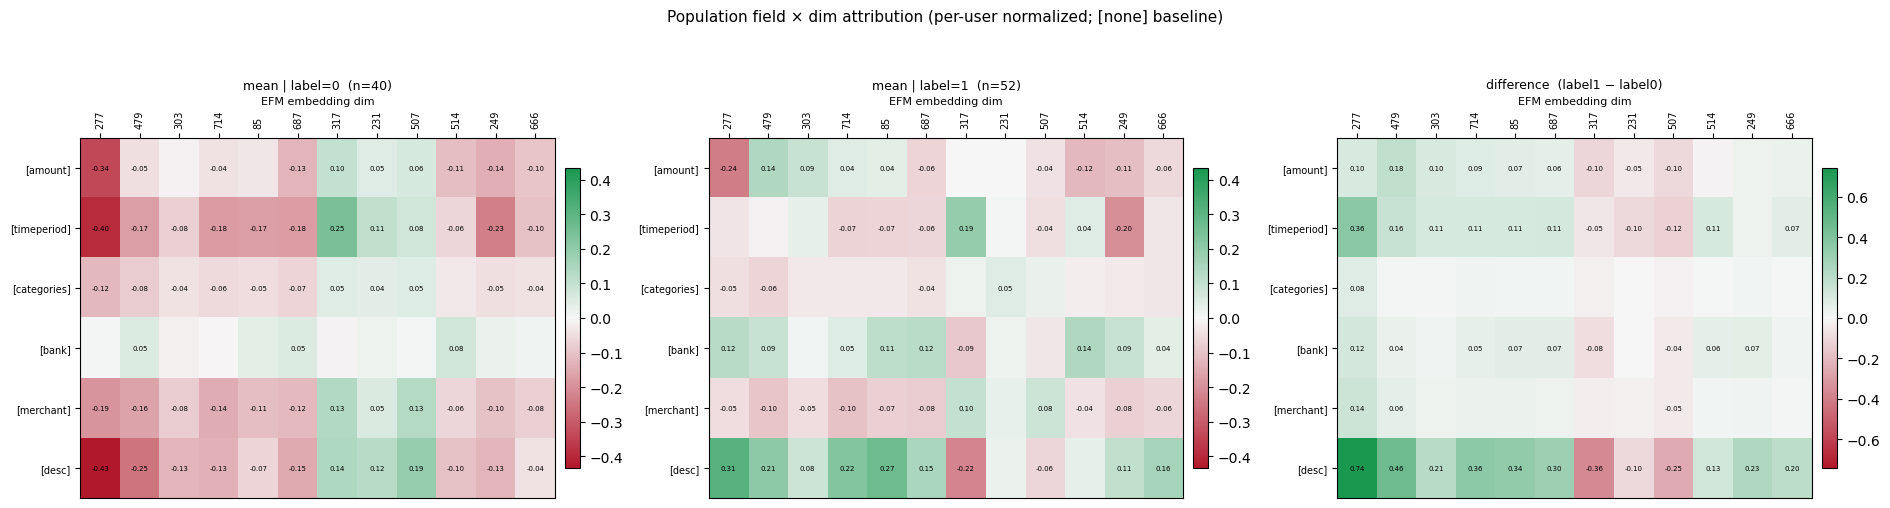

In [17]:
# === AGG 1: population field x dim, split by label (per-user normalized, then averaged) ===
# Aggregated version of per-user VIZ 2. Structural field rows are SHARED across all users, so this is the
# natural population view. Per user: roll content up to its field marker (structural_field_matrix from the
# VIZ-2 cell), normalize by that user's max|.| (PATTERN, not magnitude), then average within each label
# group. Panels: mean(label=0), mean(label=1), and the difference (label1 - label0 = what differs for failures).
# Non-contributing rows ([bos]/[eos]/[txn_sep]/[txn_type], ~0 under [none]) are dropped via KEEP_IDX (same as VIZ 2).
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
RWG = LinearSegmentedColormap.from_list("red_white_green", ["#b2182b", "#f7f7f7", "#1a9850"])

def _norm_field_mats(results, dims, struct_list):
    g0, g1 = [], []
    for res in results.values():
        M = structural_field_matrix(res["token_ids"], res["attr"], struct_list, dims)[KEEP_IDX]  # drop ~0 seam/held-fixed rows
        m = np.abs(M).max()
        if m > 0:
            M = M / m                                  # per-user normalize -> unit max|.|
        (g1 if res["label"] == 1.0 else g0).append(M)
    return g0, g1

if not pop_results:
    print("Scaled run paused (RUN_SCALED=False) — skipping AGG 1 (field x dim by label).")
else:
    g0, g1 = _norm_field_mats(pop_results, TOP_DIMS, STRUCT_LIST)
    shp   = (len(FIELD_ROWS), len(TOP_DIMS))
    mean0 = np.mean(g0, axis=0) if g0 else np.zeros(shp)
    mean1 = np.mean(g1, axis=0) if g1 else np.zeros(shp)
    diff  = mean1 - mean0
    mm    = max(float(np.abs(mean0).max()), float(np.abs(mean1).max())) or 1.0     # shared scale for the means
    dm    = float(np.abs(diff).max()) or 1.0                                       # own scale for the difference
    panels = [(f"mean | label=0  (n={len(g0)})", mean0, mm),
              (f"mean | label=1  (n={len(g1)})", mean1, mm),
              ("difference  (label1 − label0)", diff, dm)]

    fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
    for ax, (title, M, scale) in zip(axes, panels):
        im = ax.imshow(M, cmap=RWG, norm=TwoSlopeNorm(0.0, -scale, scale), aspect="auto")
        ax.set_xticks(range(len(TOP_DIMS))); ax.set_xticklabels([str(d) for d in TOP_DIMS], fontsize=7, rotation=90)
        ax.set_yticks(range(len(FIELD_ROWS))); ax.set_yticklabels(FIELD_ROWS, fontsize=7)
        ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
        ax.set_xlabel("EFM embedding dim", fontsize=8)
        for r in range(M.shape[0]):
            for c in range(M.shape[1]):
                if abs(M[r, c]) > 0.04:
                    ax.text(c, r, f"{M[r, c]:.2f}", ha="center", va="center", fontsize=5)
        ax.set_title(title, fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    fig.suptitle("Population field × dim attribution (per-user normalized; [none] baseline)", fontsize=11, y=1.05)
    plt.tight_layout(); plt.show()

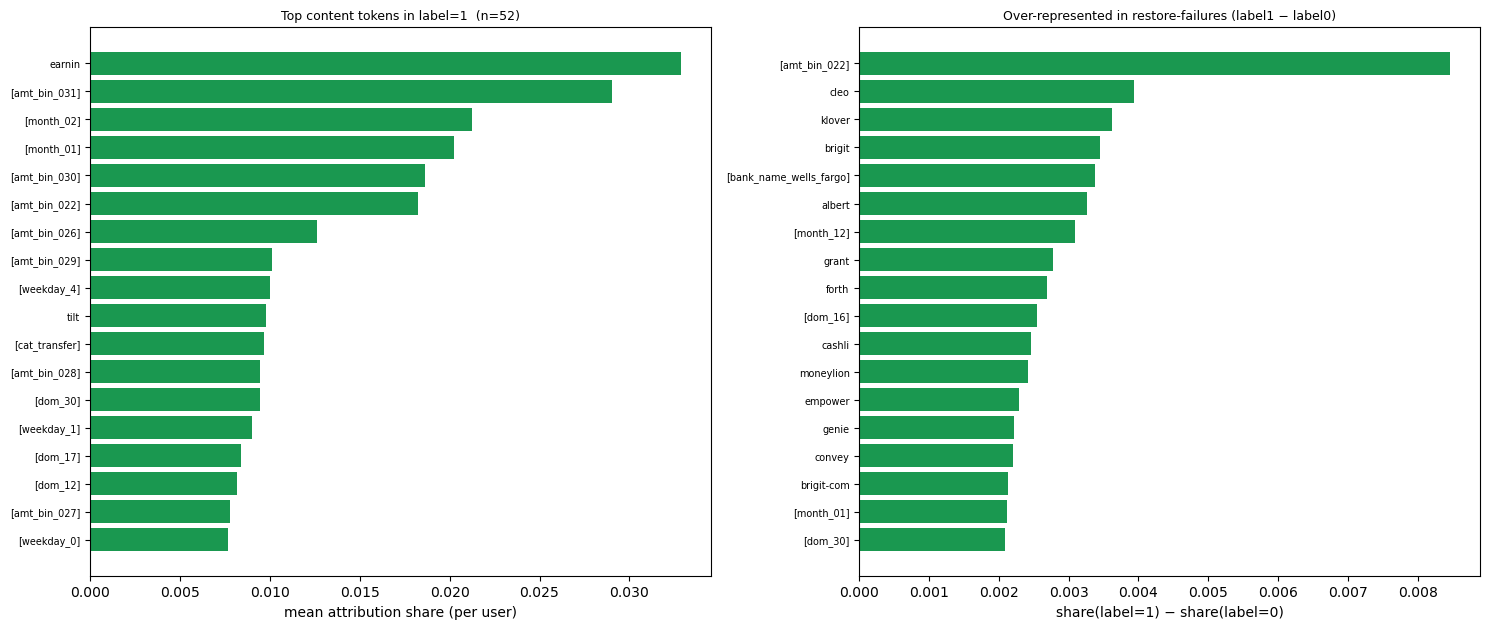

NOTE: shares are small (many distinct tokens) — read as RANKING, not magnitude. label=1 n=52 is small, so the differential is noisy.


In [18]:
# === AGG 2: content-token (entity) ranking by label — pooled token-level attribution across users ===
# Per user: importance[pos] = Σ_dims |attr_d[pos]| (total influence the token drives across the 12 top
# dims). Normalize to a SHARE (sums to 1 per user) so every user is weighted equally, then group by token
# STRING and average within each label class. Left: top content tokens in label=1. Right: differential
# (share label1 − share label0) = entities OVER-represented in restore-failures. Read token TYPE from its
# prefix ([bank_name_*]/[cat_*]/[amt_bin_*]/merchant text). Structural markers excluded.
import matplotlib.pyplot as plt
from collections import defaultdict

def content_share_by_label(results, dims, struct_ids, id2tok):
    grp = {0.0: defaultdict(float), 1.0: defaultdict(float)}; cnt = {0.0: 0, 1.0: 0}
    for res in results.values():
        lbl = res["label"]; cnt[lbl] = cnt.get(lbl, 0) + 1
        tok_ids = res["token_ids"]
        imp = np.zeros(len(tok_ids))
        for d in dims:
            imp += np.abs(res["attr"][d]["per_token"])          # total |attr| across the 12 dims, per position
        tot = imp.sum() or 1.0
        for i, t in enumerate(tok_ids):
            if t in struct_ids:
                continue
            grp[lbl][id2tok.get(t, str(t))] += imp[i] / tot     # per-user share -> equal weight per user
    share = {lbl: {s: v / max(cnt[lbl], 1) for s, v in d.items()} for lbl, d in grp.items()}
    return share, cnt

if not pop_results:
    print("Scaled run paused (RUN_SCALED=False) — skipping AGG 2 (entity ranking by label).")
else:
    share, cnt = content_share_by_label(pop_results, TOP_DIMS, STRUCT_IDS, id2tok)
    toks = set(share[0.0]) | set(share[1.0])
    s1 = {t: share[1.0].get(t, 0.0) for t in toks}
    s0 = {t: share[0.0].get(t, 0.0) for t in toks}
    diff = {t: s1[t] - s0[t] for t in toks}
    TOPN = 18
    top_pos = sorted(s1, key=s1.get, reverse=True)[:TOPN]                 # most important in label=1
    over    = sorted(diff, key=diff.get, reverse=True)[:TOPN]             # most over-represented in label=1

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6.4))
    yL = np.arange(len(top_pos))
    axL.barh(yL, [s1[t] for t in top_pos], color="#1a9850")
    axL.set_yticks(yL); axL.set_yticklabels(top_pos, fontsize=7); axL.invert_yaxis()
    axL.set_xlabel("mean attribution share (per user)")
    axL.set_title(f"Top content tokens in label=1  (n={cnt.get(1.0, 0)})", fontsize=9)
    yR = np.arange(len(over))
    axR.barh(yR, [diff[t] for t in over], color=["#1a9850" if diff[t] >= 0 else "#b2182b" for t in over])
    axR.set_yticks(yR); axR.set_yticklabels(over, fontsize=7); axR.invert_yaxis()
    axR.axvline(0, color="k", lw=0.6)
    axR.set_xlabel("share(label=1) − share(label=0)")
    axR.set_title("Over-represented in restore-failures (label1 − label0)", fontsize=9)
    plt.tight_layout(); plt.show()
    print("NOTE: shares are small (many distinct tokens) — read as RANKING, not magnitude. "
          f"label=1 n={cnt.get(1.0, 0)} is small, so the differential is noisy.")

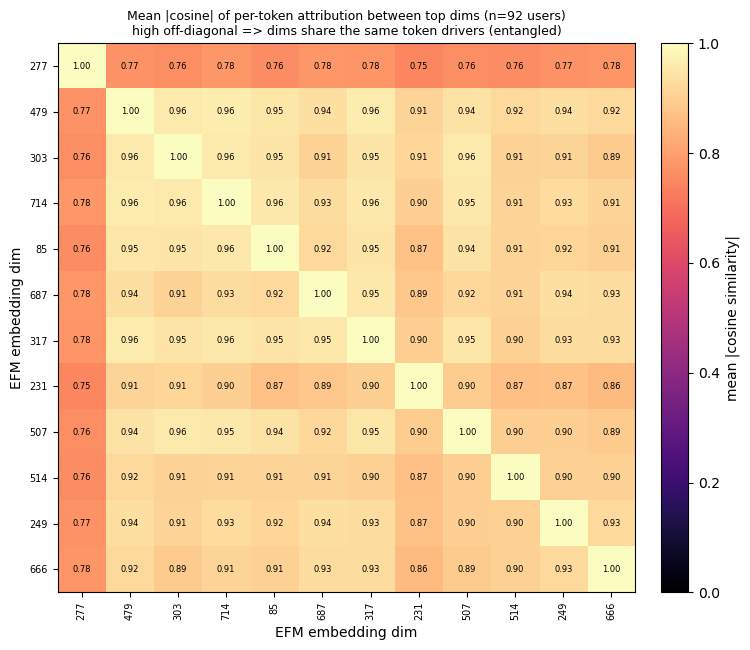

mean off-diagonal |cosine| = 0.896  (0 = orthogonal/independent, 1 = identical support)


In [19]:
# === AGG 3: dim-redundancy heatmap (12x12) — do the top dims share token drivers? ===
# For each user build the (12, T) matrix of per-token attribution vectors (one row per top dim),
# L2-normalize each row, take the cosine-similarity matrix, and average |cosine| across ALL users.
# High off-diagonal |cos| => the dims fire on the SAME tokens (entangled / polysemantic) — the population
# version of the per-user VIZ-3 finding (the same ~5-6 tokens recur across all 12 dims, often sign-flipped).
import matplotlib.pyplot as plt

def dim_redundancy(results, dims):
    D = len(dims); acc = np.zeros((D, D)); k = 0
    for res in results.values():
        V = np.stack([res["attr"][d]["per_token"] for d in dims]).astype(np.float64)   # (D, T)
        nrm = np.linalg.norm(V, axis=1, keepdims=True); nrm[nrm == 0] = 1.0
        Vn = V / nrm
        acc += np.abs(Vn @ Vn.T); k += 1                                                # |cosine| per user
    return acc / max(k, 1)

if not pop_results:
    print("Scaled run paused (RUN_SCALED=False) — skipping AGG 3 (dim-redundancy heatmap).")
else:
    R = dim_redundancy(pop_results, TOP_DIMS)
    fig, ax = plt.subplots(figsize=(7.6, 6.6))
    im = ax.imshow(R, cmap="magma", vmin=0.0, vmax=1.0, aspect="auto")
    ax.set_xticks(range(len(TOP_DIMS))); ax.set_xticklabels([str(d) for d in TOP_DIMS], fontsize=7, rotation=90)
    ax.set_yticks(range(len(TOP_DIMS))); ax.set_yticklabels([str(d) for d in TOP_DIMS], fontsize=7)
    ax.set_xlabel("EFM embedding dim"); ax.set_ylabel("EFM embedding dim")
    for r in range(len(TOP_DIMS)):
        for c in range(len(TOP_DIMS)):
            ax.text(c, r, f"{R[r, c]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if R[r, c] < 0.6 else "black")
    ax.set_title(f"Mean |cosine| of per-token attribution between top dims (n={len(pop_results)} users)\n"
                 "high off-diagonal => dims share the same token drivers (entangled)", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="mean |cosine similarity|")
    plt.tight_layout(); plt.show()
    mean_off = (R.sum() - np.trace(R)) / (R.size - len(TOP_DIMS))
    print(f"mean off-diagonal |cosine| = {mean_off:.3f}  (0 = orthogonal/independent, 1 = identical support)")